<a href="https://colab.research.google.com/github/Avhijit-Nair/SINDy-Transformer-Physics-Informed-Diffusion-Model/blob/main/Another_copy_of_SINDy%2BTransformer_Physics_Informed_Diffusion_Model_for_Synthetic_Data_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# All Imports

# Colab Setup

In [1]:
try:
    import google.colab
    COLAB = True
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    COLAB = False

# Make use of a GPU or MPS (Apple) if one is available.  (see module 3.2)
import torch
has_mps = torch.backends.mps.is_built()
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Note: using Google CoLab
Using device: cuda
Mounted at /content/drive


# Import libraries

In [2]:
import numpy as np
import gdown
import pandas as pd
import math
import gc
import pickle
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from torch.cuda.amp import autocast, GradScaler

# EDA

In [3]:
training_dataset_file_path= '/content/drive/MyDrive/ColabNotebooks/combined_data_training.csv'
validation_dataset_file_path= '/content/drive/MyDrive/ColabNotebooks/combined_data_validation.csv'
training_dataset = pd.read_csv(training_dataset_file_path)
validation_dataset = pd.read_csv(validation_dataset_file_path)

In [4]:
training_dataset_healthy = training_dataset[(training_dataset['gearset_state']==0) & (training_dataset['bearingset_state']==0)]
training_dataset_singleFault = training_dataset[((training_dataset['gearset_state']!=0)&(training_dataset['bearingset_state']==0))|
                                                 ((training_dataset['bearingset_state']!=0)&(training_dataset['gearset_state']==0))]
training_dataset_compoundFault = training_dataset[(training_dataset['gearset_state']!=0)&(training_dataset['bearingset_state']!=0)]

In [5]:
validation_dataset_healthy = validation_dataset[(validation_dataset['gearset_state']==0) & (validation_dataset['bearingset_state']==0)]
validation_dataset_singleFault = validation_dataset[((validation_dataset['gearset_state']!=0)&(validation_dataset['bearingset_state']==0))|
                                                 ((validation_dataset['bearingset_state']!=0)&(validation_dataset['gearset_state']==0))]
validation_dataset_compoundFault = validation_dataset[(validation_dataset['gearset_state']!=0)&(validation_dataset['bearingset_state']!=0)]

# Data Preprocessing

In [6]:
from scipy.signal import savgol_filter

In [ ]:
# def smooth_data(data, window_length=11, polyorder=3):
#     """
#     Smooth data using Savitzky-Golay filtering.

#     Args:
#         data: Input data [n_samples, n_features]
#         window_length: The length of the filter window (must be a positive odd integer).
#         polyorder: The order of the polynomial used to fit the samples.

#     Returns:
#         smoothed_data: Smoothed data
#     """
#     if isinstance(data, torch.Tensor):
#         data_np = data.detach().cpu().numpy()
#     else:
#         data_np = data

#     smoothed_data = np.zeros_like(data_np)
#     for j in range(data_np.shape[1]):  # Loop over each feature
#         if data_np.shape[0] < window_length:
#             # Handle case when data length is shorter than window length
#             smoothed_data[:,j] = data_np[:,j]  # set smoothed data to data
#         else:
#             smoothed_data[:,j] = savgol_filter(data_np[:, j], window_length, polyorder)

#     return smoothed_data

In [7]:
from sklearn.preprocessing import StandardScaler


# For data preparation, you'd want all sensors data as both input and output
sensor_columns = ['motor_vibration', 'gearbox_vibration_x', 'gearbox_vibration_y',
                 'gearbox_vibration_z', 'motor_torque']

# The condition columns will be used as conditioning information
condition_columns_cat = ['gearset_state', 'bearingset_state']
conditions_columns_cont = ['rotating_speed','load']

# Next, fit the scaler on training data only
sensors_data_training = training_dataset[sensor_columns].values
sensors_data_validation= validation_dataset[sensor_columns].values

# Define sensor data scaler
scaler = StandardScaler()
scaler.fit(sensors_data_training)

# Then transform both datasets using the same scaler
X_sensors_data_training = scaler.transform(sensors_data_training).astype(np.float32)
X_sensors_data_validation = scaler.transform(sensors_data_validation).astype(np.float32)

X_sensors_data_training_dot = savgol_filter(X_sensors_data_training, window_length=5, polyorder=2)
X_sensors_data_validation_dot = savgol_filter(X_sensors_data_validation, window_length=5, polyorder=2)

X_sensors_data_training_healthy = X_sensors_data_training[training_dataset_healthy.index]
X_sensors_data_training_dot_healthy = X_sensors_data_training_dot[training_dataset_healthy.index]
X_sensors_data_training_singleFault = X_sensors_data_training[training_dataset_singleFault.index]
X_sensors_data_training_dot_singleFault = X_sensors_data_training_dot[training_dataset_singleFault.index]
X_sensors_data_training_compoundFault = X_sensors_data_training[training_dataset_compoundFault.index]
X_sensors_data_training_dot_compoundFault = X_sensors_data_training_dot[training_dataset_compoundFault.index]

X_sensors_data_validation_healthy = X_sensors_data_validation[validation_dataset_healthy.index]
X_sensors_data_validation_dot_healthy = X_sensors_data_validation_dot[validation_dataset_healthy.index]
X_sensors_data_validation_singleFault = X_sensors_data_validation[validation_dataset_singleFault.index]
X_sensors_data_validation_dot_singleFault = X_sensors_data_validation_dot[validation_dataset_singleFault.index]
X_sensors_data_validation_compoundFault = X_sensors_data_validation[validation_dataset_compoundFault.index]
X_sensors_data_validation_dot_compoundFault = X_sensors_data_validation_dot[validation_dataset_compoundFault.index]
# selected_sensor_features = select_features_lasso(X_sensors_data_training, dXdt_sensors_data_training, alpha=0.01)

# Scale continuous values from condition data
condition_cont_training = training_dataset[conditions_columns_cont].values
condition_cont_validation = validation_dataset[conditions_columns_cont].values
scaler_cont = StandardScaler()
scaler_cont.fit(condition_cont_training)
X_condition_cont_training = scaler_cont.transform(condition_cont_training).astype(np.float32)
X_condition_cont_validation = scaler_cont.transform(condition_cont_validation).astype(np.float32)

X_condition_cont_training_healthy = X_condition_cont_training[training_dataset_healthy.index]
X_condition_cont_training_singleFault = X_condition_cont_training[training_dataset_singleFault.index]
X_condition_cont_training_compoundFault = X_condition_cont_training[training_dataset_compoundFault.index]

X_condition_cont_validation_healthy = X_condition_cont_validation[validation_dataset_healthy.index]
X_condition_cont_validation_singleFault = X_condition_cont_validation[validation_dataset_singleFault.index]
X_condition_cont_validation_compoundFault = X_condition_cont_validation[validation_dataset_compoundFault.index]

# Get condition data (One Hot encode categorical variables)
X_conditions_training_healthy_oneHotEncoding = pd.get_dummies(training_dataset_healthy[condition_columns_cat]).astype(int)
X_conditions_training_singleFault_oneHotEncoding = pd.get_dummies(training_dataset_singleFault[condition_columns_cat]).astype(int)
X_conditions_training_compoundFault_oneHotEncoding = pd.get_dummies(training_dataset_compoundFault[condition_columns_cat]).astype(int)

X_conditions_validation_healthy_oneHotEncoding = pd.get_dummies(validation_dataset_healthy[condition_columns_cat]).astype(int)
X_conditions_validation_healthy_oneHotEncoding = X_conditions_validation_healthy_oneHotEncoding.reindex(columns=X_conditions_training_healthy_oneHotEncoding.columns, fill_value=0)
X_conditions_validation_singleFault_oneHotEncoding = pd.get_dummies(validation_dataset_singleFault[condition_columns_cat]).astype(int)
X_conditions_validation_singleFault_oneHotEncoding = X_conditions_validation_singleFault_oneHotEncoding.reindex(columns=X_conditions_training_singleFault_oneHotEncoding.columns, fill_value=0)
X_conditions_validation_compoundFault_oneHotEncoding = pd.get_dummies(validation_dataset_compoundFault[condition_columns_cat]).astype(int)
X_conditions_validation_compoundFault_oneHotEncoding = X_conditions_validation_compoundFault_oneHotEncoding.reindex(columns=X_conditions_training_compoundFault_oneHotEncoding.columns, fill_value=0)



X_train_healthy = np.hstack([X_sensors_data_training_healthy, X_conditions_training_healthy_oneHotEncoding, X_condition_cont_training_healthy])
X_train_healthy_dot = np.hstack([X_sensors_data_training_dot_healthy,X_conditions_training_healthy_oneHotEncoding ,X_condition_cont_training_healthy])

X_train_singleFault = np.hstack([X_sensors_data_training_singleFault, X_conditions_training_singleFault_oneHotEncoding, X_condition_cont_training_singleFault])
X_train_singleFault_dot = np.hstack([X_sensors_data_training_dot_singleFault,X_conditions_training_singleFault_oneHotEncoding ,X_condition_cont_training_singleFault])

X_train_compoundFault = np.hstack([X_sensors_data_training_compoundFault, X_conditions_training_compoundFault_oneHotEncoding, X_condition_cont_training_compoundFault])
X_train_compoundFault_dot = np.hstack([X_sensors_data_training_dot_compoundFault,X_conditions_training_compoundFault_oneHotEncoding ,X_condition_cont_training_compoundFault])

X_val_healthy = np.hstack([X_sensors_data_validation_healthy, X_conditions_validation_healthy_oneHotEncoding, X_condition_cont_validation_healthy])
X_val_healthy_dot = np.hstack([X_sensors_data_validation_dot_healthy,X_conditions_validation_healthy_oneHotEncoding,X_condition_cont_validation_healthy])

X_val_singleFault = np.hstack([X_sensors_data_validation_singleFault, X_conditions_validation_singleFault_oneHotEncoding, X_condition_cont_validation_singleFault])
X_val_singleFault_dot = np.hstack([X_sensors_data_validation_dot_singleFault,X_conditions_validation_singleFault_oneHotEncoding,X_condition_cont_validation_singleFault])

X_val_compoundFault = np.hstack([X_sensors_data_validation_compoundFault, X_conditions_validation_compoundFault_oneHotEncoding, X_condition_cont_validation_compoundFault])
X_val_compoundFault_dot = np.hstack([X_sensors_data_validation_dot_compoundFault,X_conditions_validation_compoundFault_oneHotEncoding,X_condition_cont_validation_compoundFault])

In [ ]:
scaler_cont.mean_

array([25.,  1.])

In [ ]:
print("NaNs in X_sensors_data_training_dot:", np.isnan(X_sensors_data_training_dot).sum())
print("Infs in X_sensors_data_training_dot:", np.isinf(X_sensors_data_training_dot).sum())

NaNs in X_sensors_data_training_dot: 0
Infs in X_sensors_data_training_dot: 0


In [ ]:
X_train_singleFault_dot[0:3,:]

array([[ 0.20272781, -0.2962099 , -0.60016608, -0.70914078, -0.6231339 ,
         0.        ,  1.        , -1.        , -1.        ],
       [ 0.08002786,  0.19397345,  0.20624775,  0.11685074, -0.07421757,
         0.        ,  1.        , -1.        , -1.        ],
       [ 0.2038046 , -0.07191143, -0.17876303, -0.11675023,  0.11412699,
         0.        ,  1.        , -1.        , -1.        ]])

In [ ]:
def plot_savgol_tuning(X, dt=1/2000, feature_idx=0, window_lengths=[10000], polyorders=[2, 3, 4]):
    plt.figure(figsize=(14, 6))
    time = np.arange(X.shape[0]) * dt
    plt.plot(time, X[:, feature_idx], label='Original', alpha=0.5, color='gray')

    for w in window_lengths:
        for p in polyorders:
            if w > p:
                dXdt_sg = savgol_filter(X[:, feature_idx], window_length=w, polyorder=p, deriv=1, delta=dt)
                plt.plot(time, dXdt_sg, label=f'win={w}, poly={p}')

    plt.title(f'Savitzky-Golay Derivative Tuning (feature {feature_idx})')
    plt.xlabel('Time')
    plt.ylabel('Derivative')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
X_sensors_data_training.shape

(16776960, 5)

In [ ]:
plot_savgol_tuning(X_sensors_data_training)

In [ ]:
plot_savgol_tuning(X_sensors_data_training, polyorders=[2,3])

In [ ]:
X_sensors_data_training = smooth_data(X_sensors_data_training, window_length=125, polyorder=2)

In [ ]:
plot_savgol_tuning(X_sensors_data_training, window_lengths=[125],polyorders=[2,3,4],feature_idx=0)

# Another Sindy Implementation

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.special import comb
from itertools import combinations_with_replacement
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [9]:
class LearnableFeatureLibrary(nn.Module):
    """
    Feature library with learnable components for SINDy.
    Includes polynomial, Fourier, and cross-term features.
    """
    def __init__(self, input_dim, poly_order=2, n_fourier_freqs=3, include_cross_terms=True):
        super().__init__()
        self.input_dim = input_dim
        self.poly_order = poly_order
        self.n_fourier_freqs = n_fourier_freqs
        self.include_cross_terms = include_cross_terms

        # Learnable Fourier frequencies: shape (n_fourier_freqs, input_dim)
        # Initialize with reasonable frequency range to capture different timescales
        init_freqs = torch.linspace(0.1, 2.0, n_fourier_freqs).unsqueeze(1).repeat(1, input_dim)
        init_freqs = init_freqs * (1 + 0.1 * torch.randn(n_fourier_freqs, input_dim))
        self.frequencies = nn.Parameter(init_freqs.to(device))

        # Precompute polynomial feature combinations for cross terms
        self.poly_combinations = []
        if include_cross_terms:
            for order in range(2, poly_order + 1):
                self.poly_combinations += list(combinations_with_replacement(range(input_dim), order))
        else:
            # Only pure powers, no cross terms
            self.poly_combinations = [(i,) for i in range(input_dim) for _ in range(2, poly_order + 1)]

        # Count features
        self.n_poly_features = 1 + input_dim + len(self.poly_combinations)  # constant + linear + poly
        self.n_fourier_features = 2 * n_fourier_freqs * input_dim
        self.n_features = self.n_poly_features + self.n_fourier_features

    def _n_combinations_with_replacement(self, n, r):
        """Calculate binomial coefficient (n+r-1)C(r)."""
        return comb(n + r - 1, r, exact=True)

    def get_feature_names(self):
        """Generate human-readable names for all features."""
        feature_names = ['1']  # Constant term

        # Linear terms
        for i in range(self.input_dim):
            feature_names.append(f'x{i+1}')

        # Higher order polynomial terms with cross terms
        if self.include_cross_terms:
            # Quadratic terms
            if self.poly_order >= 2:
                for i in range(self.input_dim):
                    for j in range(i, self.input_dim):
                        if i == j:
                            feature_names.append(f'x{i+1}²')
                        else:
                            feature_names.append(f'x{i+1}·x{j+1}')

            # Cubic terms
            if self.poly_order >= 3:
                for i in range(self.input_dim):
                    for j in range(i, self.input_dim):
                        for k in range(j, self.input_dim):
                            if i == j == k:
                                feature_names.append(f'x{i+1}³')
                            elif i == j:
                                feature_names.append(f'x{i+1}²·x{k+1}')
                            elif j == k:
                                feature_names.append(f'x{i+1}·x{j+1}²')
                            else:
                                feature_names.append(f'x{i+1}·x{j+1}·x{k+1}')

            # Quartic terms
            if self.poly_order >= 4:
                for i in range(self.input_dim):
                    for j in range(i, self.input_dim):
                        for k in range(j, self.input_dim):
                            for l in range(k, self.input_dim):
                                # For brevity, we'll simplify notation for quartic terms
                                if i == j == k == l:
                                    feature_names.append(f'x{i+1}⁴')
                                else:
                                    idx = [i, j, k, l]
                                    powers = {}
                                    for idx_val in idx:
                                        if idx_val+1 not in powers:
                                            powers[idx_val+1] = 1
                                        else:
                                            powers[idx_val+1] += 1

                                    term = ""
                                    for var, power in powers.items():
                                        if power == 1:
                                            term += f'x{var}·'
                                        else:
                                            term += f'x{var}^{power}·'
                                    term = term[:-1]  # Remove trailing dot
                                    feature_names.append(term)
        else:
            # Just pure powers, no cross terms
            for order in range(2, self.poly_order + 1):
                for i in range(self.input_dim):
                    feature_names.append(f'x{i+1}^{order}')

        # Fourier terms
        for i in range(self.input_dim):
            for j in range(self.n_fourier_freqs):
                feature_names.append(f'sin(ω{j+1}·x{i+1})')
                feature_names.append(f'cos(ω{j+1}·x{i+1})')

        return feature_names

    def forward(self, x):
        """
        Generate feature library Θ(x)
        x: [batch_size, input_dim]
        returns: [batch_size, n_features]
        """
        batch_size = x.shape[0]
        device = x.device

        # Constant term
        features = [torch.ones(batch_size, 1, device=device)]

        # Linear terms
        features.append(x)

        # Polynomial terms (cross terms)
        if self.include_cross_terms:
            # Vectorized polynomial features for cross terms
            for comb in self.poly_combinations:
                # Multiply corresponding features element-wise
                prod = torch.ones(batch_size, device=device)
                for idx in comb:
                    prod = prod * x[:, idx]
                features.append(prod.unsqueeze(1))
        else:
            # Pure powers only
            for i in range(self.input_dim):
                for order in range(2, self.poly_order + 1):
                    features.append((x[:, i] ** order).unsqueeze(1))

        poly_features = torch.cat(features, dim=1)  # [batch_size, n_poly_features]

        # Fourier features (vectorized)
        # x: [batch_size, input_dim], frequencies: [n_fourier_freqs, input_dim]
        x_exp = x.unsqueeze(1)  # [batch_size, 1, input_dim]
        freqs = self.frequencies.unsqueeze(0)  # [1, n_fourier_freqs, input_dim]
        args = x_exp * freqs  # [batch_size, n_fourier_freqs, input_dim]

        sin_features = torch.sin(args).reshape(batch_size, -1)
        cos_features = torch.cos(args).reshape(batch_size, -1)
        fourier_features = torch.cat([sin_features, cos_features], dim=1)  # [batch_size, n_fourier_features]

        # Combine polynomial and Fourier features
        theta = torch.cat([poly_features, fourier_features], dim=1)
        return theta

In [10]:
class AdaptiveSparsityLayer(nn.Module):
    """
    Implements adaptive sparsity regularization with learnable weights.
    """
    def __init__(self, n_features, output_dim, sparsity_mode='adaptive'):
        super().__init__()
        self.n_features = n_features
        self.output_dim = output_dim
        self.sparsity_mode = sparsity_mode

        # Coefficient matrix Ξ to be learned
        self.coeffs = nn.Parameter(0.01 * torch.randn(n_features, output_dim, device=device))

        if sparsity_mode == 'adaptive':
            # Adaptive sparsity weights (logarithm of the weights)
            # Working in log space helps numerical stability and ensures weights remain positive
            self.log_sparsity_weights = nn.Parameter(torch.zeros(n_features, output_dim, device=device))
        else:
            self.register_buffer('log_sparsity_weights', torch.zeros(n_features, output_dim, device=device))

    @property
    def sparsity_weights(self):
        """Get the actual sparsity weights by exponentiating."""
        if self.sparsity_mode == 'adaptive':
            return torch.exp(self.log_sparsity_weights)
        else:
            return torch.ones_like(self.log_sparsity_weights)

    def forward(self, theta):
        """
        Apply the coefficient matrix to the feature library.

        Args:
            theta: Feature tensor from library of shape [batch_size, n_features]

        Returns:
            Predicted output of shape [batch_size, output_dim]
        """
        return torch.matmul(theta, self.coeffs)

    def get_sparse_coeffs(self, threshold=0.01):
        """
        Return sparse coefficients with small values thresholded to zero.

        Args:
            threshold: Threshold for setting coefficients to zero

        Returns:
            Sparse coefficient matrix
        """
        with torch.no_grad():
            actual_coeffs = self.coeffs.clone()
            # Set small values to zero
            actual_coeffs[torch.abs(actual_coeffs) < threshold] = 0.0
            return actual_coeffs

    def sparsity_penalty(self, mode='l1'):
        """
        Calculate the sparsity penalty.

        Args:
            mode: Type of penalty ('l1' or 'l2')

        Returns:
            Penalty term for loss function
        """
        # Element-wise product with sparsity weights
        weighted_coeffs = self.sparsity_weights * self.coeffs

        if mode == 'l1':
            # L1 penalty
            return torch.sum(torch.abs(weighted_coeffs))
        elif mode == 'l2':
            # L2 penalty
            return torch.sum(weighted_coeffs ** 2)
        else:
            raise ValueError(f"Unsupported penalty mode: {mode}")



In [11]:
class AdamSINDy(nn.Module):
    """
    Complete Adam-optimized SINDy model with learnable features and adaptive sparsity.
    """
    def __init__(self,
                 input_dim,
                 output_dim,
                 poly_order=2,
                 n_fourier_freqs=3,
                 include_cross_terms=False,
                 sparsity_mode='adaptive'):
        super().__init__()
        # Create the feature library
        self.library = LearnableFeatureLibrary(
            input_dim,
            poly_order=poly_order,
            n_fourier_freqs=n_fourier_freqs,
            include_cross_terms=include_cross_terms
        )

        # Create the coefficient layer with adaptive sparsity
        self.sparse_layer = AdaptiveSparsityLayer(
            self.library.n_features,
            output_dim,
            sparsity_mode=sparsity_mode
        )

        # Store feature count for reference
        self.n_features = self.library.n_features
        self.feature_names = self.library.get_feature_names()

    def forward(self, x):
        """
        Forward pass of the SINDy model.

        Args:
            x: Input tensor of shape [batch_size, input_dim]

        Returns:
            Predicted derivatives of shape [batch_size, output_dim]
        """
        theta = self.library(x)
        return self.sparse_layer(theta)

    def sparsity_penalty(self, mode='l1'):
        """Get the sparsity penalty term."""
        return self.sparse_layer.sparsity_penalty(mode)

    def get_sparse_coefficients(self, threshold=0.01):
        """Get the thresholded sparse coefficients."""
        return self.sparse_layer.get_sparse_coeffs(threshold)

    def get_equations(self, threshold=0.01, precision=4):
        """
        Get the discovered equations in human-readable form.

        Args:
            threshold: Coefficient threshold for inclusion in equations
            precision: Number of decimal places to show in coefficients

        Returns:
            List of equation strings, one for each output dimension
        """
        sparse_coeffs = self.get_sparse_coefficients(threshold).cpu().detach().numpy()
        equations = []

        for i in range(sparse_coeffs.shape[1]):
            eq = f"d(x{i+1})/dt = "
            terms = []

            for j, coef in enumerate(sparse_coeffs[:, i]):
                if abs(coef) >= threshold:
                    term = f"{coef:.{precision}f} * {self.feature_names[j]}"
                    # Simplify representation for cleaner equations
                    term = term.replace("* 1", "")
                    terms.append(term)

            if terms:
                eq += " + ".join(terms)
            else:
                eq += "0"

            equations.append(eq)

        return equations


In [12]:
def train_adam_sindy(model, X, dXdt, epochs=5000, batch_size=None, lr=0.0001, lambda_reg=0.1,
                    threshold=0.05, patience=200, reg_mode='l2', verbose=True,validation_X=None, validation_dXdt=None):
    """
    Train the Adam-SINDy model.

    Args:
        model: AdamSINDy model
        X: Input state data [n_samples, n_features]
        dXdt: Derivative data [n_samples, n_features]
        epochs: Number of training epochs
        batch_size: Batch size (None = use all data)
        lr: Learning rate for Adam optimizer
        lambda_reg: Regularization strength
        threshold: Threshold for coefficient sparsity
        patience: Early stopping patience
        reg_mode: Regularization mode ('l1' or 'l2')
        verbose: Whether to print progress

    Returns:
        Trained model and training history
    """
    model.to(device)
    # Convert inputs to tensors if they aren't already
    X = X.to(device) if isinstance(X, torch.Tensor) else torch.tensor(X, dtype=torch.float32, device=device)
    dXdt = dXdt.to(device) if isinstance(dXdt, torch.Tensor) else torch.tensor(dXdt, dtype=torch.float32, device=device)

    n_samples = X.shape[0]

    # Set up optimizer
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Learning Rate Scheduler (ReduceLROnPlateau)
    # Reduces LR when a metric has stopped improving
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=50, verbose=False)

    # Use full batch if batch_size is None
    if batch_size is None or batch_size > n_samples:
        batch_size = n_samples

    # For early stopping
    best_loss = float('inf')
    best_model_state = None
    no_improve_epochs = 0

    # Training history
    history = {
        'loss': [],
        'mse_loss': [],
        'reg_loss': [],
        'val_loss': [],        # Add validation loss
        'val_mse_loss': [],    # Add validation MSE
        'sparsity':[]
    }

    # Validation Tensors
    if validation_X is not None and validation_dXdt is not None:
        validation_X = validation_X.to(device) if isinstance(validation_X, torch.Tensor) else torch.tensor(validation_X, dtype=torch.float32, device=device)
        validation_dXdt = validation_dXdt.to(device) if isinstance(validation_dXdt, torch.Tensor) else torch.tensor(validation_dXdt, dtype=torch.float32, device=device)

    # Training loop
    iterator = tqdm(range(epochs)) if verbose else range(epochs)
    for epoch in iterator:
        # Use all data if batch_size >= n_samples
        if batch_size == n_samples:
            X_batch, dXdt_batch = X, dXdt
        else:
            # Random batch
            idx = torch.randperm(n_samples)[:batch_size]
            X_batch, dXdt_batch = X[idx], dXdt[idx]

        optimizer.zero_grad()
        # Forward pass
        dXdt_pred = model(X_batch)

        # Compute loss
        eps = 1e-6
        mse_loss = torch.mean((dXdt_pred - dXdt_batch) ** 2)
        reg_loss = lambda_reg * model.sparsity_penalty(mode=reg_mode)
        loss = mse_loss + reg_loss
        # loss = torch.sqrt(mse_loss+eps) + reg_loss

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Validation (if validation data is provided)
        if validation_X is not None and validation_dXdt is not None:
            with torch.no_grad():
                model.eval()  # Set to evaluation mode
                val_dXdt_pred = model(validation_X)
                val_mse_loss = torch.mean((val_dXdt_pred - validation_dXdt) ** 2)
                val_loss = val_mse_loss + lambda_reg * model.sparsity_penalty(mode=reg_mode)
                # val_loss = torch.sqrt(val_mse_loss + eps) + lambda_reg * model.sparsity_penalty(mode=reg_mode)
                model.train()  # Set back to training mode

        # Record history
        history['loss'].append(loss.item())
        history['mse_loss'].append(mse_loss.item())
        history['reg_loss'].append(reg_loss.item())
        history['val_loss'].append(val_loss.item() if (validation_X is not None and validation_dXdt is not None) else None)
        history['val_mse_loss'].append(val_mse_loss.item() if (validation_X is not None and validation_dXdt is not None) else None)

        with torch.no_grad():
          sparse_coeffs = model.get_sparse_coefficients(threshold)
          n_active = torch.sum(torch.abs(sparse_coeffs) >= threshold).item()
        sparsity = 1.0 - (n_active / sparse_coeffs.numel())
        history['sparsity'].append(sparsity)

        # Reduce Learning Rate if no improvement is seen
        scheduler.step(val_loss if (validation_X is not None and validation_dXdt is not None) else loss)

        # Display progress
        if verbose and epoch % 100 == 0:
            with torch.no_grad():
                sparse_coeffs = model.get_sparse_coefficients(threshold)
                n_active = torch.sum(torch.abs(sparse_coeffs) >= threshold).item()
                sparsity = 1.0 - (n_active / sparse_coeffs.numel())

                log_str = f"Epoch {epoch}: Loss = {loss.item():.6f}, MSE = {mse_loss.item():.6f}, " \
                          f"Reg = {reg_loss.item():.6f}, Sparsity = {sparsity:.2f}"

                if validation_X is not None and validation_dXdt is not None:
                    log_str += f", Val Loss = {val_loss.item():.6f}, Val MSE = {val_mse_loss.item():.6f}"

                tqdm.write(log_str)

        # Early stopping
        if validation_X is not None and validation_dXdt is not None:
            current_loss = val_loss.item()
        else:
            current_loss = loss.item()

        if current_loss < best_loss:
            best_loss = current_loss
            best_model_state = {key: val.clone() for key, val in model.state_dict().items()}
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1

        if no_improve_epochs >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch}")
            break

    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, history

In [ ]:
# def numerical_differentiation(X, dt=1.0, method='central'):
#     """
#     Compute numerical derivatives using finite differences.

#     Args:
#         X: Input data [n_samples, n_features]
#         dt: Time step
#         method: Differentiation method ('central', 'forward', or 'backward')

#     Returns:
#         dXdt: Numerical derivatives
#     """
#     if isinstance(X, torch.Tensor):
#         X_np = X.detach().cpu().numpy()
#     else:
#         X_np = X

#     n_samples, n_features = X_np.shape
#     dXdt = np.zeros_like(X_np)

#     if method == 'central':
#         # Central differences for interior points
#         dXdt[1:-1] = (X_np[2:] - X_np[:-2]) / (2 * dt)
#         # Forward difference for first point
#         dXdt[0] = (X_np[1] - X_np[0]) / dt
#         # Backward difference for last point
#         dXdt[-1] = (X_np[-1] - X_np[-2]) / dt
#     elif method == 'forward':
#         # Forward differences
#         dXdt[:-1] = (X_np[1:] - X_np[:-1]) / dt
#         # Last point - use backward
#         dXdt[-1] = (X_np[-1] - X_np[-2]) / dt
#     elif method == 'backward':
#         # Backward differences
#         dXdt[1:] = (X_np[1:] - X_np[:-1]) / dt
#         # First point - use forward
#         dXdt[0] = (X_np[1] - X_np[0]) / dt
#     else:
#         raise ValueError(f"Unsupported differentiation method: {method}")

#     return dXdt

(16776960, 9)   (16776960, 9)


In [18]:
adam_sindy_model_healthy = AdamSINDy(input_dim=X_train_healthy.shape[1], output_dim=X_train_healthy_dot.shape[1], poly_order=2, n_fourier_freqs=2,include_cross_terms=True)
adam_sindy_model_singleFault = AdamSINDy(input_dim=X_train_singleFault.shape[1], output_dim=X_train_singleFault_dot.shape[1], poly_order=2, n_fourier_freqs=2,include_cross_terms=True)
# adam_sindy_model_compoundFault = AdamSINDy(input_dim=X_train_compoundFault.shape[1], output_dim=X_train_compoundFault_dot.shape[1], poly_order=2, n_fourier_freqs=2,include_cross_terms=True)

In [ ]:
sindy_model_healthy, history_healthy = train_adam_sindy(model = adam_sindy_model_healthy, X=X_train_healthy, dXdt=X_train_healthy_dot,lambda_reg=0.03,lr=1e-4, threshold=0.01, verbose=True,validation_X=X_val_healthy, validation_dXdt=X_val_healthy_dot)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
  0%|          | 3/5000 [00:01<23:54,  3.48it/s]  

Epoch 0: Loss = 1.874345, MSE = 1.871845, Reg = 0.002499, Sparsity = 0.67, Val Loss = 0.508066, Val MSE = 0.505582


  2%|▏         | 103/5000 [00:07<05:12, 15.67it/s]

Epoch 100: Loss = 0.615681, MSE = 0.613632, Reg = 0.002049, Sparsity = 0.75, Val Loss = 0.461521, Val MSE = 0.459470


  4%|▍         | 203/5000 [00:13<05:06, 15.63it/s]

...

 96%|█████████▌| 4803/5000 [05:07<00:12, 15.67it/s]

Epoch 4800: Loss = 0.031370, MSE = 0.015163, Reg = 0.016207, Sparsity = 0.83, Val Loss = 0.029106, Val MSE = 0.012902


 98%|█████████▊| 4903/5000 [05:13<00:06, 15.65it/s]

Epoch 4900: Loss = 0.030354, MSE = 0.014376, Reg = 0.015979, Sparsity = 0.83, Val Loss = 0.028168, Val MSE = 0.012192


100%|██████████| 5000/5000 [05:19<00:00, 15.65it/s]


In [19]:
sindy_model_singleFault, history_singleFault = train_adam_sindy(model=adam_sindy_model_singleFault, X=X_train_singleFault, dXdt=X_train_singleFault_dot,lambda_reg=0.03,lr=1e-4, threshold=0.01, verbose=True, validation_X=X_val_singleFault, validation_dXdt=X_val_singleFault_dot)

  0%|          | 1/5000 [00:00<21:43,  3.84it/s]

Epoch 0: Loss = 1.401434, MSE = 1.399017, Reg = 0.002417, Sparsity = 0.69, Val Loss = 1.188339, Val MSE = 1.185930


  2%|▏         | 101/5000 [00:25<20:49,  3.92it/s]

Epoch 100: Loss = 0.965919, MSE = 0.963159, Reg = 0.002760, Sparsity = 0.67, Val Loss = 0.919122, Val MSE = 0.916351


  4%|▍         | 201/5000 [00:51<20:23,  3.92it/s]

...

 96%|█████████▌| 4801/5000 [20:20<00:50,  3.92it/s]

Epoch 4800: Loss = 0.020831, MSE = 0.008512, Reg = 0.012319, Sparsity = 0.71, Val Loss = 0.020225, Val MSE = 0.007908


 98%|█████████▊| 4901/5000 [20:46<00:25,  3.91it/s]

Epoch 4900: Loss = 0.020321, MSE = 0.008179, Reg = 0.012142, Sparsity = 0.71, Val Loss = 0.019740, Val MSE = 0.007600


100%|██████████| 5000/5000 [21:11<00:00,  3.93it/s]


In [ ]:
X_train_singleFault_dot.shape

(13421568, 9)

In [ ]:
X_train_compoundFault.shape

(0, 9)

In [ ]:
def evaluate_adam_sindy(model, X, dXdt, threshold=0.05):
    """
    Evaluate the Adam-SINDy model.

    Args:
        model: Trained AdamSINDy model
        X: Test input data
        dXdt: Test derivative data
        threshold: Coefficient threshold

    Returns:
        Dictionary of evaluation metrics
    """
    model.to(device)
    # Convert to tensors if needed
    X = X.to(device) if isinstance(X, torch.Tensor) else torch.tensor(X, dtype=torch.float32, device=device)
    dXdt = dXdt.to(device) if isinstance(dXdt, torch.Tensor) else torch.tensor(dXdt, dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        # Predict derivatives
        dXdt_pred = model(X)

        # Calculate MSE
        mse = torch.mean((dXdt_pred - dXdt) ** 2).item()

        # Calculate R^2 score for each output dimension
        var = torch.var(dXdt, dim=0)
        mse_per_dim = torch.mean((dXdt_pred - dXdt) ** 2, dim=0)
        r2_per_dim = 1 - mse_per_dim / var
        r2_score = torch.mean(r2_per_dim).item()

        # Get sparse coefficients
        sparse_coeffs = model.get_sparse_coefficients(threshold)
        n_active = torch.sum(torch.abs(sparse_coeffs) >= threshold).item()
        sparsity = 1.0 - (n_active / sparse_coeffs.numel())

        # Get the equations
        equations = model.get_equations(threshold)

    return {
        'mse': mse,
        'r2_score': r2_score,
        'sparsity': sparsity,
        'n_active_terms': n_active,
        'equations': equations
    }

In [ ]:
mse_val, r2_score_val,sparsity_val, n_active_terms_val, equations_val = evaluate_adam_sindy(sindy_model_healthy, X_val_healthy, X_val_healthy_dot).values()

In [ ]:
mse_val, r2_score_val,sparsity_val, n_active_terms_val, equations_val = evaluate_adam_sindy(sindy_model_singleFault, X_val_singleFault, X_val_singleFault_dot).values()

In [ ]:
print("mse_val: ",mse_val,"r2_score_val: ",r2_score_val,"sparsity_val: ",sparsity_val, "n_active_terms_val: ",n_active_terms_val)

mse_val:  0.011526261456310749 r2_score_val:  -inf sparsity_val:  0.9267399267399268 n_active_terms_val:  60


In [ ]:
# variance of the target
np.var(X_val_singleFault_dot)

np.float64(1.1389456767363668)

In [ ]:
sindy_model_healthy.get_equations(threshold=0.01)

['d(x1)/dt = -0.0246  + 0.1955 * x1 + 0.1024 * x2 + -0.0676 * x3 + -0.1222 * x4 + 0.0699 * x5 + -0.0826 * x1² + 0.0171 * x1·x2 + 0.0123 * x1·x3 + 0.0245 * x1·x4 + 0.0187 * x1·x8 + 0.0258 * x1·x9 + 0.0106 * x2·x8 + 0.0123 * x2·x9 + -0.0195 * x8² + -0.0211 * x8·x9 + -0.0236 * x9² + 0.2516 * sin(ω1·x1) + 0.0599 * cos(ω1·x1) + -0.0299 * sin(ω2·x1) + -0.0413 * cos(ω2·x1) + 0.0213 * sin(ω1·x2) + 0.1602 * cos(ω1·x3) + 0.1068 * sin(ω2·x3) + -0.0100 * sin(ω1·x4) + 0.2219 * sin(ω2·x5) + -0.0329 * cos(ω2·x5) + -0.0283 * sin(ω1·x6) + -0.0315 * cos(ω1·x6) + -0.0188 * sin(ω2·x6) + -0.0172 * cos(ω2·x6) + -0.0203 * sin(ω1·x7) + -0.0191 * cos(ω1·x7) + -0.0221 * sin(ω2·x7) + 0.1392 * cos(ω2·x7) + -0.0252 * sin(ω1·x8) + -0.0228 * cos(ω1·x8) + -0.0141 * sin(ω2·x8) + -0.0214 * cos(ω2·x8) + -0.0251 * sin(ω1·x9) + -0.0176 * cos(ω1·x9)',
 'd(x2)/dt = 0.0856 * x1 + 0.1357 * x2 + 0.2056 * x3 + 0.1413 * x4 + -0.1151 * x5 + -0.0202 * x1² + -0.0114 * x1·x2 + 0.0134 * x2·x3 + 0.0719 * sin(ω1·x1) + 0.1290 * cos(ω1·x

In [ ]:
sindy_model_singleFault.get_equations(threshold=0.01)

['d(x1)/dt = 0.1393 * x1 + 0.0499 * x2 + -0.0438 * x3 + -0.0793 * x4 + 0.0406 * x5 + 0.0105 * x6 + -0.0211 * x7 + -0.0498 * x1² + 0.0199 * x1·x4 + 0.1331 * x1·x6 + 0.1517 * x1·x7 + 0.0117 * x1·x8 + 0.0120 * x1·x9 + 0.0404 * x2·x6 + 0.0392 * x2·x7 + 0.0175 * x2·x8 + 0.0199 * x2·x9 + -0.0160 * x4·x6 + -0.0172 * x4·x7 + 0.0111 * x5·x6 + 0.0109 * x5·x7 + 0.0872 * sin(ω1·x1) + 0.0147 * cos(ω1·x1) + -0.0184 * sin(ω2·x1) + -0.0251 * cos(ω2·x1) + 0.0150 * sin(ω1·x2) + -0.0148 * sin(ω2·x2) + 0.0808 * cos(ω1·x3) + 0.0442 * sin(ω2·x3) + 0.0570 * cos(ω2·x4) + 0.0629 * sin(ω2·x5) + 0.0553 * cos(ω2·x7)',
 'd(x2)/dt = 0.0472 * x1 + 0.1017 * x2 + 0.1413 * x3 + 0.1044 * x4 + -0.0767 * x5 + -0.0109 * x1² + -0.0148 * x1·x2 + 0.0385 * x1·x6 + 0.0548 * x1·x7 + 0.0580 * x2·x6 + 0.0598 * x2·x7 + 0.0110 * x2·x8 + 0.0113 * x2·x9 + 0.0494 * x3·x6 + 0.0453 * x3·x7 + 0.0127 * x3·x8 + 0.0132 * x3·x9 + 0.0156 * x4·x6 + 0.0154 * x4·x7 + -0.0149 * x5·x6 + -0.0149 * x5·x7 + 0.0181 * sin(ω1·x1) + 0.0315 * cos(ω1·x1) + 

In [25]:
def plot_results(X, dXdt, model, history=None, dt=1.0, threshold=0.05):
    """
    Plot the results of the Adam-SINDy model.

    Args:
        X: Input data
        dXdt: Derivative data
        model: Trained AdamSINDy model
        history: Training history
        dt: Time step
        threshold: Coefficient threshold
    """
    # Convert to tensors if needed
    if not isinstance(X, torch.Tensor):
        X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    else:
        X_tensor = X.to(device)

    model.eval()
    with torch.no_grad():
        # Predict derivatives
        dXdt_pred = model(X_tensor).detach().cpu().numpy()

    if isinstance(dXdt, torch.Tensor):
        dXdt = dXdt.detach().cpu().numpy()

    # Create the figure
    fig = plt.figure(figsize=(15, 12))

    # Subplot 1: Training history
    # if history is not None:
    #     ax1 = fig.add_subplot(2, 2, 1)
    #     ax1.semilogy(history['loss'], label='Total Loss')
    #     ax1.semilogy(history['mse_loss'], label='MSE Loss')
    #     ax1.semilogy(history['reg_loss'], label='Reg Loss')
    #     ax1.set_xlabel('Epoch')
    #     ax1.set_ylabel('Loss')
    #     ax1.set_title('Training History')
    #     ax1.legend()
    #     ax1.grid(True)

    # plt.show()

    # # Subplot 2: Original vs Predicted derivatives
    n_vars = dXdt.shape[1]
    # ax2 = fig.add_subplot(2, 2, 2)
    # time_points = np.arange(len(dXdt)) * dt

    # for i in range(min(n_vars, 3)):  # Plot up to 3 variables
    #     ax2.plot(time_points, dXdt[:, i], label=f'True dx{i+1}/dt', alpha=0.7)
    #     ax2.plot(time_points, dXdt_pred[:, i], '--', label=f'Pred dx{i+1}/dt')

    # ax2.set_xlabel('Time')
    # ax2.set_ylabel('Derivative')
    # ax2.set_title('Original vs Predicted Derivatives')
    # ax2.legend()
    # ax2.grid(True)
    # plt.show()

    # # Subplot 3: Coefficient matrix as heatmap
    # ax3 = fig.add_subplot(2, 2, 3)
    # sparse_coeffs = model.get_sparse_coefficients(threshold).detach().cpu().numpy()

    # # Get feature names (shortened for display)
    # feature_names = model.feature_names
    # short_names = [name[:10] + '...' if len(name) > 10 else name for name in feature_names]

    # # Create heatmap
    # im = ax3.imshow(sparse_coeffs, cmap='viridis', aspect='auto')
    # ax3.set_title('Sparse Coefficient Matrix')
    # ax3.set_xlabel('Output Dimension')
    # ax3.set_ylabel('Library Function')

    # # Set y-ticks for library functions (limit if too many)
    # if len(short_names) <= 20:
    #     ax3.set_yticks(np.arange(len(short_names)))
    #     ax3.set_yticklabels(short_names)
    # else:
    #     # Show a subset of features if there are too many
    #     step = len(short_names) // 20 + 1
    #     ax3.set_yticks(np.arange(0, len(short_names), step))
    #     ax3.set_yticklabels([short_names[i] for i in range(0, len(short_names), step)])

    # # Set x-ticks for output dimensions
    # ax3.set_xticks(np.arange(n_vars))
    # ax3.set_xticklabels([f'dx{i+1}/dt' for i in range(n_vars)])

    # # Add colorbar
    # plt.colorbar(im, ax=ax3)
    # plt.show()

    # Subplot 4: Equations
    ax4 = fig.add_subplot(2, 2, 4)
    equations = model.get_equations(threshold)
    ax4.axis('off')
    ax4.text(0.05, 0.95, 'Discovered Equations:', fontsize=12, fontweight='bold',
             verticalalignment='top')

    for i, eq in enumerate(equations):
        # Simplify equation for display
        eq = eq.replace(" + -", " - ")
        eq = eq.replace("+ -", "- ")
        ax4.text(0.05, 0.85 - i*0.1, eq, fontsize=10, verticalalignment='top')

    plt.tight_layout()
    plt.show()
    # plt.savefig('adam_sindy_results.png')
    plt.close()

In [26]:
plot_results(X_train_healthy,X_train_healthy_dot,sindy_model_healthy,history = history_healthy, dt = 1/2000)

NameError: name 'sindy_model_healthy' is not defined

In [ ]:
history_singleFault = checkpoint['history']

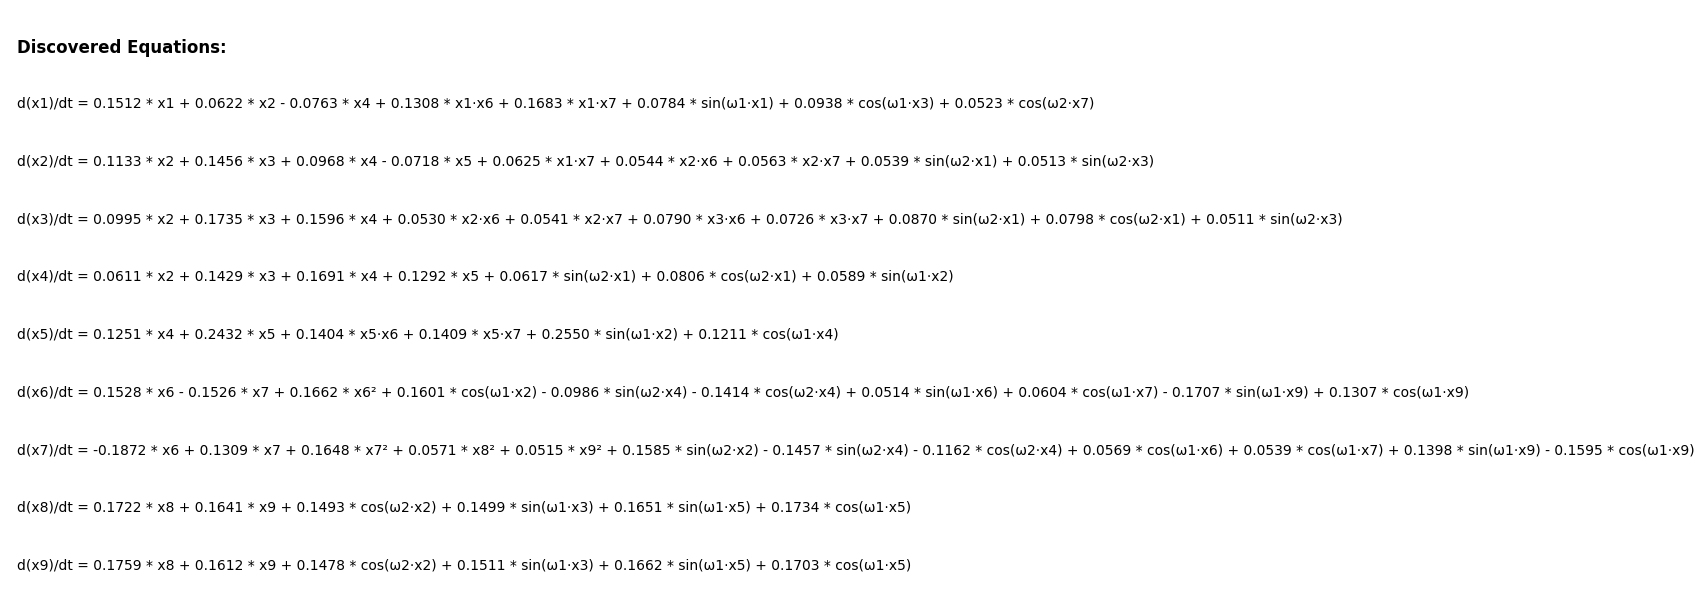

In [27]:
plot_results(X_train_singleFault,X_train_singleFault_dot,adam_sindy_model_singleFault,history = history_singleFault, dt = 1/2000)

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# def plot_residuals(true_deriv, pred_deriv, feature_names, num_features=3):
#     n_samples = true_deriv.shape[0]
#     plt.figure(figsize=(12, 4 * num_features))
#     for i in range(num_features):
#         plt.subplot(num_features, 1, i + 1)
#         residuals = true_deriv[:, i] - pred_deriv[:, i]
#         plt.plot(residuals, label=f'Residuals for {feature_names[i]}')
#         plt.axhline(0, color='k', linestyle='--')
#         plt.legend()
#         plt.xlabel('Time')
#         plt.ylabel('Residual')
#     plt.tight_layout()
#     plt.show()



In [ ]:
# X_dash = X.to(device) if isinstance(X, torch.Tensor) else torch.tensor(X, dtype=torch.float32, device=device)
# X_dot_pred = sindy_model(X_dash)

OutOfMemoryError: CUDA out of memory. Tried to allocate 576.00 MiB. GPU 0 has a total capacity of 39.56 GiB of which 50.88 MiB is free. Process 3212 has 39.50 GiB memory in use. Of the allocated memory 38.89 GiB is allocated by PyTorch, and 113.81 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
path_healthy = "/content/drive/MyDrive/IEEE IES/checkpoints/adam-sindy-healthy-latest.pth"
# torch.save(sindy_model_healthy.state_dict(), path)

In [14]:
path_singleFault = "/content/drive/MyDrive/IEEE IES/checkpoints/adam-sindy-singleFault-latest.pth"
# torch.save(sindy_model_singleFault.state_dict(), path)

In [15]:
adam_sindy_model_singleFault.load_state_dict(torch.load(path_singleFault))

<All keys matched successfully>

In [ ]:
adam_sindy_model_healthy.load_state_dict(torch.load(path_healthy))

NameError: name 'path_healthy' is not defined

In [ ]:
import torch

BATCH_SIZE = 1024  # or smaller if needed
X = X_train_singleFault  # or whatever array you want to check

num_samples = X.shape[0]
n_nan, n_inf = 0, 0

adam_sindy_model_singleFault.eval()
with torch.no_grad():
    for start in range(0, num_samples, BATCH_SIZE):
        end = min(start + BATCH_SIZE, num_samples)
        batch = torch.from_numpy(X[start:end]).type(torch.float32).to(device) # Changed to float32
        pred = adam_sindy_model_singleFault(batch)
        n_nan += torch.isnan(pred).sum().item()
        n_inf += torch.isinf(pred).sum().item()
        del batch, pred
        torch.cuda.empty_cache()

print(f"NaNs in SINDy output: {n_nan}")
print(f"Infs in SINDy output: {n_inf}")

NaNs in SINDy output: 0
Infs in SINDy output: 0


# Sequence Data Preparation

In [ ]:
def create_sequences_for_generation(sensor_data, condition_data_cat, condition_data_cont, seq_length=32, stride=1, prediction_length=1):
    """
    Create input-output pairs where:
    - Input: sequence of sensors data + conditions data
    - Output: next sensor data values
    """
    X_seq = []
    y_seq = []
    condition_cat_seq = []
    condition_cont_seq = []

    for i in range(0,len(sensor_data) - seq_length - prediction_length + 1, stride):
        # Input sequence
        X_seq.append(sensor_data[i:i+seq_length])

        # Output is the next timestep's sensor values
        y_seq.append(sensor_data[i+seq_length:i+seq_length+prediction_length])

        # Full condition sequence for this window
        condition_cat_seq.append(condition_data_cat[i:i+seq_length])
        condition_cont_seq.append(condition_data_cont[i:i+seq_length])

    return np.array(X_seq), np.array(y_seq), np.array(condition_cat_seq), np.array(condition_cont_seq)

# Create sequences for training
stride = 4
seq_length = 150
batch_size = 256

X_sensor_train_healthy_seq, y_sensor_train_healthy_next, X_condition_cat_healthy_train_seq, X_condition_cont_healthy_train_seq = create_sequences_for_generation(
    X_sensors_data_training_healthy, X_conditions_training_healthy_oneHotEncoding, X_condition_cont_training_healthy, seq_length, stride =stride)
X_sensor_test_healthy_seq, y_sensor_test_healthy_next, X_condition_cat_healthy_test_seq, X_condition_cont_healthy_test_seq = create_sequences_for_generation(
    X_sensors_data_validation_healthy, X_conditions_validation_healthy_oneHotEncoding, X_condition_cont_validation_healthy, seq_length, stride=stride)

X_sensor_train_singleFault_seq, y_sensor_train_singleFault_next, X_condition_cat_singleFault_train_seq, X_condition_cont_singleFault_train_seq = create_sequences_for_generation(
    X_sensors_data_training_singleFault, X_conditions_training_singleFault_oneHotEncoding, X_condition_cont_training_singleFault, seq_length, stride =stride
)
X_sensor_test_singleFault_seq, y_sensor_test_singleFault_next, X_condition_cat_singleFault_test_seq, X_condition_cont_singleFault_test_seq = create_sequences_for_generation(
    X_sensors_data_validation_singleFault, X_conditions_validation_singleFault_oneHotEncoding, X_condition_cont_validation_singleFault, seq_length, stride=stride
)

# Convert numpy arrays to tensors
X_sensor_train_tensor_healthy = torch.FloatTensor(X_sensor_train_healthy_seq).to(device)
y_sensor_train_tensor_healthy = torch.FloatTensor(y_sensor_train_healthy_next).to(device)
X_condition_cat_train_tensor_healthy = torch.FloatTensor(X_condition_cat_healthy_train_seq).to(device)
X_condition_cont_train_tensor_healthy = torch.FloatTensor(X_condition_cont_healthy_train_seq).to(device)

X_sensor_test_tensor_healthy = torch.FloatTensor(X_sensor_test_healthy_seq).to(device)
y_sensor_test_tensor_healthy = torch.FloatTensor(y_sensor_test_healthy_next).to(device)
X_condition_cat_test_tensor_healthy = torch.FloatTensor(X_condition_cat_healthy_test_seq).to(device)
X_condition_cont_test_tensor_healthy = torch.FloatTensor(X_condition_cont_healthy_test_seq).to(device)

X_sensor_train_tensor_singleFault = torch.FloatTensor(X_sensor_train_singleFault_seq).to(device)
y_sensor_train_tensor_singleFault = torch.FloatTensor(y_sensor_train_singleFault_next).to(device)
X_condition_cat_train_tensor_singleFault = torch.FloatTensor(X_condition_cat_singleFault_train_seq).to(device)
X_condition_cont_train_tensor_singleFault = torch.FloatTensor(X_condition_cont_singleFault_train_seq).to(device)

X_sensor_test_tensor_singleFault = torch.FloatTensor(X_sensor_test_singleFault_seq).to(device)
y_sensor_test_tensor_singleFault = torch.FloatTensor(y_sensor_test_singleFault_next).to(device)
X_condition_cat_test_tensor_singleFault = torch.FloatTensor(X_condition_cat_singleFault_test_seq).to(device)
X_condition_cont_test_tensor_singleFault = torch.FloatTensor(X_condition_cont_singleFault_test_seq).to(device)

# Setup data loaders for batch training - include condition data!
train_dataset_healthy = TensorDataset(X_sensor_train_tensor_healthy, X_condition_cat_train_tensor_healthy, X_condition_cont_train_tensor_healthy, y_sensor_train_tensor_healthy)
train_loader_healthy = DataLoader(train_dataset_healthy, batch_size,shuffle=True)

test_dataset_healthy = TensorDataset(X_sensor_test_tensor_healthy, X_condition_cat_test_tensor_healthy, X_condition_cont_test_tensor_healthy, y_sensor_test_tensor_healthy)
test_loader_healthy = DataLoader(test_dataset_healthy, batch_size, shuffle=False)

train_dataset_singleFault = TensorDataset(X_sensor_train_tensor_singleFault, X_condition_cat_train_tensor_singleFault, X_condition_cont_train_tensor_singleFault, y_sensor_train_tensor_singleFault)
train_loader_singleFault = DataLoader(train_dataset_singleFault, batch_size, shuffle=False)

test_dataset_singleFault = TensorDataset(X_sensor_test_tensor_singleFault, X_condition_cat_test_tensor_singleFault, X_condition_cont_test_tensor_singleFault, y_sensor_test_tensor_singleFault)
test_loader_singleFault = DataLoader(test_dataset_singleFault, batch_size, shuffle=False)

In [ ]:
X_sensor_train_tensor_healthy.shape

torch.Size([838811, 150, 5])

# Diffusion Model Noise Scheduler

In [ ]:
class NoiseScheduler:
    def __init__(self, num_timesteps=1000, beta_start=1e-4, beta_end=0.02, device='cuda'):
        """
        Linear noise scheduler for diffusion process
        """
        self.num_timesteps = num_timesteps
        self.beta_start = beta_start
        self.beta_end = beta_end
        self.device = device

        # Define beta schedule
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)

        # Pre-compute diffusion process constants
        self.alphas = 1 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)

        # Calculations for diffusion q(x_t | x_{t-1}) and others
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - self.alphas_cumprod)
        self.sqrt_recip_alphas = torch.sqrt(1 / self.alphas)
        self.posterior_variance = self.betas * (1 - self.alphas_cumprod_prev) / (1 - self.alphas_cumprod)

    def add_noise(self, x_0, t, noise=None):
        """
        Forward diffusion process: q(x_t | x_0)
        """
        if noise is None:
            noise = torch.randn_like(x_0)

        sqrt_alphas_cumprod_t = self.sqrt_alphas_cumprod[t].reshape(-1, 1, 1)
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].reshape(-1, 1, 1)

        # Mean + variance
        x_t = sqrt_alphas_cumprod_t * x_0 + sqrt_one_minus_alphas_cumprod_t * noise
        return x_t, noise

    def sample_timesteps(self, batch_size, device):
        """Sample random timesteps for a batch"""
        return torch.randint(0, self.num_timesteps, (batch_size,), device=device)

# Transformer Based Neural Network

In [ ]:
class TimeSeriesTransformer(nn.Module):
    def __init__(
        self,
        input_dim,
        d_model=256,
        nhead=8,
        num_encoder_layers=6,
        dim_feedforward=1024,
        dropout=0.1,
        activation="gelu"
    ):
        """
        Transformer model for time series data
        """
        super().__init__()

        # Input embedding
        self.input_embedding = nn.Linear(input_dim, d_model)

        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout)

        # Transformer encoder
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation=activation,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_encoder_layers)

        # Output projection
        self.output_projection = nn.Linear(d_model, input_dim)

        self.d_model = d_model
        self.input_dim = input_dim

    def forward(self, x, mask=None):
        """
        x: [batch_size, seq_len, input_dim]
        """
        # Input embedding
        x = self.input_embedding(x)  # [batch_size, seq_len, d_model]

        # Add positional encoding
        x = self.pos_encoder(x)

        # Apply transformer encoder
        if mask is not None:
            x = self.transformer_encoder(x, src_key_padding_mask=mask)
        else:
            x = self.transformer_encoder(x)

        # Output projection
        output = self.output_projection(x)  # [batch_size, seq_len, input_dim]

        return output


# Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        Args:
            x: Tensor, shape [batch_size, seq_len, d_model]
        """
        x = x + self.pe[:x.size(1)].unsqueeze(0)
        return self.dropout(x)


# Diffusion Model Denoiser

In [ ]:
class DiffusionModel(nn.Module):
    def __init__(
        self,
        input_dim,
        scheduler,
        network,
    ):
        """
        Diffusion model for time series data
        """
        super().__init__()
        self.input_dim = input_dim
        self.scheduler = scheduler
        self.network = network

    def forward(self, x_0, t=None):
        """
        Forward pass for training
        """
        batch_size = x_0.shape[0]

        # Sample random timesteps if not provided
        if t is None:
            t = self.scheduler.sample_timesteps(batch_size, x_0.device)

        # Add noise to the input
        x_t, noise = self.scheduler.add_noise(x_0, t)

        # Predict the noise
        noise_pred = self.network(x_t)

        return noise_pred, noise, x_t, t

    @torch.no_grad()
    def sample(self, batch_size, seq_len, device):
        """
        Sample new time series data
        """
        # Start from random noise
        x = torch.randn(batch_size, seq_len, self.input_dim, device=device)

        # Iteratively denoise
        for t in reversed(range(self.scheduler.num_timesteps)):
            t_tensor = torch.full((batch_size,), t, device=device, dtype=torch.long)

            # 1. Predict noise
            predicted_noise = self.network(x)

            # 2. Get alpha values for current timestep
            alpha = self.scheduler.alphas[t]
            alpha_cumprod = self.scheduler.alphas_cumprod[t]
            beta = self.scheduler.betas[t]

            # No noise for the last step (t=0)
            if t > 0:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)

            # Compute the denoised x_0
            x_0_pred = (x - beta * predicted_noise / torch.sqrt(1 - alpha_cumprod)) / torch.sqrt(alpha)

            # Compute the coefficient for x_0_pred
            c1 = torch.sqrt(alpha_cumprod) * beta / (1 - alpha_cumprod)

            # Compute the coefficient for x
            c2 = torch.sqrt(alpha) * (1 - alpha_cumprod - beta) / (1 - alpha_cumprod)

            # Update x
            x = x_0_pred * c1 + x * c2 + torch.sqrt(beta) * noise

        return x

# Physics Informed Diffusion Model

In [ ]:
import copy
class PhysicsInformedDiffusionModel(nn.Module):
    def __init__(
        self,
        input_dim,
        seq_len,
        d_model=256,
        nhead=8,
        num_encoder_layers=6,
        dim_feedforward=1024,
        dropout=0.1,
        num_timesteps=1000,
        beta_start=1e-4,
        beta_end=0.02,
        poly_order=2,
        lambda_physics=1,
        sindy_model = None
    ):
        super().__init__()

        self.scheduler = NoiseScheduler(num_timesteps, beta_start, beta_end)
        self.network = TimeSeriesTransformer(
            input_dim=input_dim,
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout
        )
        self.diffusion = DiffusionModel(input_dim, self.scheduler, self.network)

        #self.sindy_library = SINDyLibrary(input_dim, poly_order, include_sine)
        # self.physics_loss = PhysicsInformedLoss(
        #     sindy_library=self.sindy_library,
        #     sparse_weights=sindy_coeffs,      # <<<<<<<< USE THE PASSED WEIGHTS
        #     lambda_physics=lambda_physics
        # )
        # sindy_model_clone = copy.deepcopy(sindy_model).to(device)
        self.physics_loss = PhysicsInformedLoss(
            sindy_model=sindy_model,
            lambda_physics=lambda_physics
        )
        self.input_dim = input_dim
        self.seq_len = seq_len
        self.lambda_physics = lambda_physics

    def forward(self, x_0, t=None):
        noise_pred, noise, x_t, t = self.diffusion(x_0, t)

        diffusion_loss = F.mse_loss(noise_pred, noise)

        # Predict clean data from noisy sample
        alpha_cumprod = self.scheduler.alphas_cumprod[t].reshape(-1, 1, 1)
        sqrt_one_minus_alphas_cumprod = self.scheduler.sqrt_one_minus_alphas_cumprod[t].reshape(-1, 1, 1)
        x_0_pred = (x_t - sqrt_one_minus_alphas_cumprod * noise_pred) / torch.sqrt(alpha_cumprod)

        phys_loss = self.physics_loss(x_0_pred)

        total_loss = diffusion_loss + phys_loss

        return total_loss, diffusion_loss, phys_loss

    @torch.no_grad()
    def sample(self, batch_size, device):
        return self.diffusion.sample(batch_size, self.seq_len, device)


# Vanilla Diffusion Model without physics informed loss

# Physics Informed Loss

In [ ]:
class PhysicsInformedLoss(nn.Module):
    def __init__(self, sindy_model, lambda_physics=1, min_vals=None, max_vals=None):
        super().__init__()
        self.sindy_model = sindy_model
        self.lambda_physics = lambda_physics
        print("lambda_physics: ",lambda_physics)
        self.min_vals = min_vals
        self.max_vals = max_vals
        for param in self.sindy_model.parameters():
            param.requires_grad = False

    def forward(self, x_pred):
      # Convert scaler parameters to torch tensors and reshape for broadcasting

        mean_sensor = torch.tensor(scaler.mean_,dtype=x_pred.dtype, device=x_pred.device)
        std_sensor = torch.tensor(scaler.scale_,dtype=x_pred.dtype, device=x_pred.device)

        mean_cont = torch.tensor(scaler_cont.mean_,dtype=x_pred.dtype, device=x_pred.device)
        std_cont = torch.tensor(scaler_cont.scale_,dtype=x_pred.dtype, device=x_pred.device)

      # Standardize sensor features (first n_sensor_features columns)
        sensor_scaled = (x_pred[:, :, :len(sensor_columns)] - mean_sensor) / std_sensor
        sensor_scaled = torch.clamp(sensor_scaled, -3, 3)

      # Leave categorical features as-is
        cat = x_pred[:, :, len(sensor_columns):len(sensor_columns)+len(condition_columns_cat)]

      # Standardize continuous features (last n_cond_cont columns)
        cont_scaled = (x_pred[:, :, -len(condition_columns_cat):] - mean_cont) / std_cont
        cont_scaled = torch.clamp(cont_scaled, -3, 3)

      # Reconstruct the tensor
        x_pred = torch.cat([sensor_scaled, cat, cont_scaled], dim=-1)
        # print("Raw x_pred: ",x_pred[0:2,:,:])
        batch_size, seq_len, input_dim = x_pred.shape
        device = x_pred.device

        # # Clamp to prevent extreme values
        # x_pred = torch.clamp(x_pred, min=-1e6, max=1e6)

        # Central difference
        dXdt_pred = (x_pred[:, 2:, :] - x_pred[:, :-2, :]) / 2.0
        x_mid = x_pred[:, 1:-1, :]
        x_mid_flat = x_mid.reshape(-1, x_mid.shape[-1])
        x_mid_flat = torch.clamp(x_mid_flat, -3, 3)

        # SINDy features
        theta = self.sindy_model.library(x_mid_flat)
        theta = torch.clamp(theta, -1e3, 1e3)
        coeffs = self.sindy_model.get_sparse_coefficients(threshold=0.01).to(device)



        dXdt_sindy = torch.matmul(theta, coeffs)
        dXdt_sindy = dXdt_sindy.view(batch_size, seq_len-2, input_dim)

        # # Clamp derivatives to avoid overflow
        # dXdt_pred = torch.clamp(dXdt_pred, min=-1e6, max=1e6)
        # dXdt_sindy = torch.clamp(dXdt_sindy, min=-1e6, max=1e6)

        # Physics loss (MSE)
        physics_loss = F.mse_loss(dXdt_pred, dXdt_sindy)
        # if torch.isnan(physics_loss) or torch.isinf(physics_loss):
        #     print("Physics loss is NaN/Inf!")
        #     print("dXdt_pred stats:", dXdt_pred.min().item(), dXdt_pred.max().item())
        #     print("dXdt_sindy stats:", dXdt_sindy.min().item(), dXdt_sindy.max().item())
        return self.lambda_physics * physics_loss


# Integrated trainer

In [ ]:
!pip install tqdm

In [ ]:
class LambdaPhysicsScheduler:
    def __init__(self, model, initial_lambda, factor=0.5, patience=5, min_lambda=0.01):
        self.model = model
        self.factor = factor
        self.patience = patience
        self.min_lambda = min_lambda
        self.best_loss = float('inf')
        self.counter = 0
        self.lambda_physics = initial_lambda
        print("lambda_physics: ",initial_lambda)

    def step(self, val_loss):
        if val_loss < self.best_loss - 1e-4:  # Small threshold for improvement
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                # Reduce lambda_physics
                new_lambda = max(self.lambda_physics * self.factor, self.min_lambda)
                if new_lambda < self.lambda_physics:
                    print(f"Reducing lambda_physics: {self.lambda_physics:.6f} -> {new_lambda:.6f}")
                    self.lambda_physics = new_lambda
                    self.model.physics_loss.lambda_physics = new_lambda
                self.counter = 0  # Reset counter


In [ ]:
import os
from tqdm import tqdm
from torch.amp import autocast, GradScaler

def train_physics_informed_diffusion(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs,
    start_epoch=0,
    save_path=None,
    initial_lambda_physics=1,
    scheduler_patience=5,
    scheduler_factor=0.5,
    early_stopping_patience=15,
    checkpoint_path=None  # Path to load checkpoint for resuming
):
    print("lambda_physics: ",initial_lambda_physics)
    # Initialize or load training history
    if checkpoint_path and os.path.isfile(checkpoint_path):
        print(f"Loading checkpoint from {checkpoint_path} to resume training...")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        history = checkpoint.get('history', {
            'train_total_loss': [],
            'train_diffusion_loss': [],
            'train_physics_loss': [],
            'val_total_loss': [],
            'val_diffusion_loss': [],
            'val_physics_loss': [],
            'lambda_physics': []
        })
        best_val_loss = checkpoint.get('val_loss', float('inf'))
        print(f"Resuming from epoch {start_epoch} with best val loss {best_val_loss:.6f}")
    else:
        history = {
            'train_total_loss': [],
            'train_diffusion_loss': [],
            'train_physics_loss': [],
            'val_total_loss': [],
            'val_diffusion_loss': [],
            'val_physics_loss': [],
            'lambda_physics': []
        }
        best_val_loss = float('inf')

    # Initialize lambda scheduler
    lambda_scheduler = LambdaPhysicsScheduler(
        model=model,
        initial_lambda=initial_lambda_physics,
        factor=scheduler_factor,
        patience=scheduler_patience
    )

    gradScaler = GradScaler()
    early_stop_counter = 0
    model.train()

    for epoch in range(start_epoch, num_epochs):
        epoch_diff_loss = 0.0
        epoch_phys_loss = 0.0
        epoch_total_loss = 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs-1}")

        for batch_idx, (data, condition_cat_data, condition_cont_data, target_data) in enumerate(pbar):
            combined_data = torch.cat([data, condition_cat_data, condition_cont_data], dim=-1).to(device)
            optimizer.zero_grad()

            with autocast(device_type=device.type):
                total_loss, diff_loss, phys_loss = model(combined_data)

            gradScaler.scale(total_loss).backward()
            gradScaler.step(optimizer)
            gradScaler.update()

            epoch_diff_loss += diff_loss.detach().item()
            epoch_phys_loss += phys_loss.detach().item()
            epoch_total_loss += total_loss.detach().item()

            pbar.set_postfix({
                'diff_loss': f"{diff_loss.item():.6f}",
                'phys_loss': f"{phys_loss.item():.6f}",
                'total_loss': f"{total_loss.item():.6f}"
            })

        # Compute average losses for the epoch
        avg_diff_loss = epoch_diff_loss / len(train_loader)
        avg_phys_loss = epoch_phys_loss / len(train_loader)
        avg_total_loss = epoch_total_loss / len(train_loader)

        print(f"Epoch {epoch} Training Summary: Avg Diff Loss={avg_diff_loss:.6f}, Avg Phys Loss={avg_phys_loss:.6f}, Avg Total Loss={avg_total_loss:.6f}")

        # Validation step every epoch (adjust if needed)
        if val_loader is not None:
            model.eval()
            val_diff_loss = 0.0
            val_phys_loss = 0.0
            val_total_loss = 0.0
            val_batches = 0
            vbar = tqdm(val_loader, desc="Validation")

            with torch.no_grad():
                for val_data, val_condition_cat_data, val_condition_cont_data, val_target_data in vbar:
                    combined_val_data = torch.cat([val_data, val_condition_cat_data, val_condition_cont_data], dim=-1).to(device)
                    total_loss, diff_loss, phys_loss = model(combined_val_data)
                    val_diff_loss += diff_loss.detach().item()
                    val_phys_loss += phys_loss.detach().item()
                    val_total_loss += total_loss.detach().item()
                    val_batches += 1
                    vbar.set_postfix({
                        'val_diff_loss': f"{diff_loss.item():.6f}",
                        'val_phys_loss': f"{phys_loss.item():.6f}",
                        'val_total_loss': f"{total_loss.item():.6f}"
                    })

            avg_val_diff_loss = val_diff_loss / val_batches
            avg_val_phys_loss = val_phys_loss / val_batches
            avg_val_total_loss = val_total_loss / val_batches

            print(f"Epoch {epoch} Validation Summary: Avg Diff Loss={avg_val_diff_loss:.6f}, Avg Phys Loss={avg_val_phys_loss:.6f}, Avg Total Loss={avg_val_total_loss:.6f}")
            print(f"lambda_physics: {model.physics_loss.lambda_physics:.6f}")

            # Update lambda_physics based on validation loss
            lambda_scheduler.step(avg_val_total_loss)

            # Append to history
            history['train_total_loss'].append(avg_total_loss)
            history['train_diffusion_loss'].append(avg_diff_loss)
            history['train_physics_loss'].append(avg_phys_loss)
            history['val_total_loss'].append(avg_val_total_loss)
            history['val_diffusion_loss'].append(avg_val_diff_loss)
            history['val_physics_loss'].append(avg_val_phys_loss)
            history['lambda_physics'].append(model.physics_loss.lambda_physics)

            # Early stopping check
            if avg_val_total_loss < best_val_loss:
                best_val_loss = avg_val_total_loss
                early_stop_counter = 0

                # Save best model checkpoint
                if save_path is not None:
                    os.makedirs(save_path, exist_ok=True)
                    checkpoint_file = os.path.join(save_path, "pi2tsd_best_model_physics.pth")
                    torch.save({
                        'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'loss': avg_val_total_loss,
                        'lambda_physics': model.physics_loss.lambda_physics,
                        'history': history,
                        'val_loss': avg_val_total_loss,
                        'train_loss': avg_total_loss
                    }, checkpoint_file)
                    print(f"Saved best model checkpoint to {checkpoint_file}")

            else:
                early_stop_counter += 1
                print(f"No improvement in validation loss. Early stop counter: {early_stop_counter}/{early_stopping_patience}")

            if early_stop_counter >= early_stopping_patience:
                print(f"Early stopping triggered at epoch {epoch}.")
                break

            model.train()

        else:
            # If no validation loader, just append train loss to history
            history['train_total_loss'].append(avg_total_loss)
            history['train_diffusion_loss'].append(avg_diff_loss)
            history['train_physics_loss'].append(avg_phys_loss)
            history['lambda_physics'].append(model.physics_loss.lambda_physics)

    return model, history


In [ ]:
# Hyperparameters
input_dim = X_train_singleFault.shape[1] # Number of variables in your time series
# seq_len = seq_length  # Length of your time series sequences
seq_len = 250  # Length of your time series sequences
batch_size = 256
learning_rate = 1e-4
num_epochs = 10
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
seq_length

150

In [ ]:
model_singleFault = PhysicsInformedDiffusionModel(
    input_dim=input_dim,
    seq_len=seq_len,
    d_model=batch_size,
    nhead=8,
    num_encoder_layers=6,
    dim_feedforward=1024,
    dropout=0.1,
    num_timesteps=1000,
    beta_start=1e-4,
    beta_end=0.02,
    poly_order=2,
    lambda_physics=0.1,
    sindy_model=adam_sindy_model_singleFault
).to(device)

lambda_physics:  0.1


In [ ]:
# Optimizer
optimizer = torch.optim.AdamW(model_singleFault.parameters(), lr=learning_rate)

In [ ]:
path_checkpoint = "/content/drive/MyDrive/IEEE IES/checkpoints/pi2tsd_best_model.pth"
checkpoint = torch.load(path_checkpoint)
model_state_dict = checkpoint['model_state_dict']
model_singleFault.load_state_dict(model_state_dict)

<All keys matched successfully>

In [ ]:
model_singleFault, history_singleFault = train_physics_informed_diffusion(
    model_singleFault,
    train_loader_singleFault,
    test_loader_singleFault,
    optimizer,
    device=device,
    num_epochs=20,
    start_epoch=14,
    save_path="/content/drive/MyDrive/IEEE IES/checkpoints/",
    checkpoint_path=path_checkpoint,
    initial_lambda_physics=1,
    early_stopping_patience=15
)

lambda_physics:  1
Loading checkpoint from /content/drive/MyDrive/IEEE IES/checkpoints/pi2tsd_best_model.pth to resume training...
Resuming from epoch 15 with best val loss 0.270725
lambda_physics:  1


Epoch 15/19: 100%|██████████| 13107/13107 [13:20<00:00, 16.37it/s, diff_loss=0.322072, phys_loss=0.680388, total_loss=1.002460]


Epoch 15 Training Summary: Avg Diff Loss=0.284991, Avg Phys Loss=0.680740, Avg Total Loss=0.965731


Validation: 100%|██████████| 3277/3277 [02:07<00:00, 25.75it/s, val_diff_loss=0.377293, val_phys_loss=0.835238, val_total_loss=1.212532]


Epoch 15 Validation Summary: Avg Diff Loss=0.387813, Avg Phys Loss=1.274749, Avg Total Loss=1.662561
lambda_physics: 1.000000
No improvement in validation loss. Early stop counter: 1/15


...

Epoch 18 Validation Summary: Avg Diff Loss=0.358578, Avg Phys Loss=1.072302, Avg Total Loss=1.430880
lambda_physics: 1.000000
No improvement in validation loss. Early stop counter: 4/15


Epoch 19/19: 100%|██████████| 13107/13107 [13:32<00:00, 16.14it/s, diff_loss=0.337830, phys_loss=0.493660, total_loss=0.831490]


Epoch 19 Training Summary: Avg Diff Loss=0.262782, Avg Phys Loss=0.481769, Avg Total Loss=0.744550


Validation: 100%|██████████| 3277/3277 [02:10<00:00, 25.19it/s, val_diff_loss=0.305750, val_phys_loss=0.649366, val_total_loss=0.955116]

Epoch 19 Validation Summary: Avg Diff Loss=0.366949, Avg Phys Loss=1.121683, Avg Total Loss=1.488632
lambda_physics: 1.000000
No improvement in validation loss. Early stop counter: 5/15


In [ ]:
pi2tsd_model, history_pi2tsd = train_physics_informed_diffusion(
    model_singleFault,
    train_loader_singleFault,
    test_loader_singleFault,
    optimizer,
    device=device,
    num_epochs=20,
    save_path="/content/drive/MyDrive/IEEE IES/checkpoints/",
    initial_lambda_physics=0.1,
    early_stopping_patience=15
)

NameError: name 'train_physics_informed_diffusion' is not defined

In [ ]:
pi2tsd_model = PhysicsInformedDiffusionModel(
    input_dim=input_dim,
    seq_len=seq_len,
    d_model=batch_size,
    nhead=8,
    num_encoder_layers=6,
    dim_feedforward=1024,
    dropout=0.1,
    num_timesteps=1000,
    beta_start=1e-4,
    beta_end=0.02,
    poly_order=2,
    lambda_physics=0.1,
    sindy_model=adam_sindy_model_singleFault
).to(device)

lambda_physics:  0.1


In [ ]:
path_checkpoint = "/content/drive/MyDrive/IEEE IES/checkpoints/pi2tsd_best_model_physics.pth"
checkpoint = torch.load(path_checkpoint)
pi2tsd_model_dict = checkpoint['model_state_dict']
pi2tsd_model.load_state_dict(pi2tsd_model_dict)

<All keys matched successfully>

In [ ]:
checkpoint['epoch']

11

In [ ]:
history = checkpoint['history']

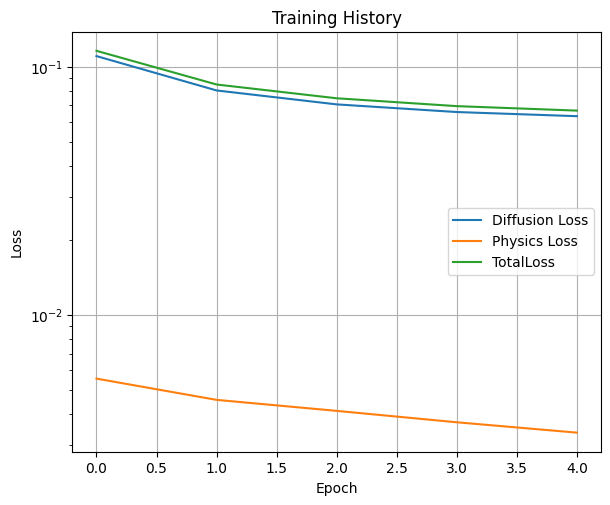

In [ ]:
import matplotlib.pyplot as plt
# Create the figure
fig = plt.figure(figsize=(15, 12))

ax1 = fig.add_subplot(2, 2, 1)
ax1.semilogy(history['train_diffusion_loss'], label='Diffusion Loss')
ax1.semilogy(history['train_physics_loss'], label='Physics Loss')
ax1.semilogy(history['train_total_loss'], label='TotalLoss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training History')
ax1.legend()
ax1.grid(True)

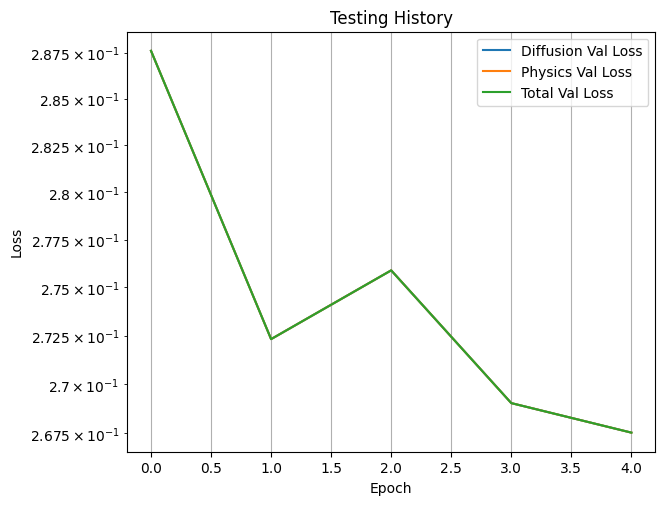

In [ ]:
import matplotlib.pyplot as plt
# Create the figure
fig = plt.figure(figsize=(15, 12))

ax1 = fig.add_subplot(2, 2, 1)
ax1.semilogy(history['val_diffusion_loss'], label='Diffusion Val Loss')
ax1.semilogy(history['val_diffusion_loss'], label='Physics Val Loss')
ax1.semilogy(history['val_diffusion_loss'], label='Total Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Testing History')
ax1.legend()
ax1.grid(True)

In [ ]:
# model = PhysicsInformedDiffusionModel(
#     input_dim=input_dim,
#     seq_len=seq_len,
#     d_model=256,
#     nhead=8,
#     num_encoder_layers=6,
#     dim_feedforward=1024,
#     dropout=0.1,
#     num_timesteps=1000,
#     beta_start=1e-4,
#     beta_end=0.02,
#     poly_order=2,
#     lambda_physics=0.00001,
#     sindy_model=sindy_model
# ).to(device)
# model.load_state_dict(torch.load(path))

<All keys matched successfully>

In [ ]:
pi2tsd_model_path = '/content/drive/MyDrive/IEEE IES/pi2tsd.pkl'
with open(pi2tsd_model_path, 'wb') as f:
  pickle.dump(trained_model, f)
print(f"Pi2tsd model saved to {pi2tsd_model_path}")

Pi2tsd model saved to /content/drive/MyDrive/IEEE IES/pi2tsd.pkl


# Synthetic data generation

In [ ]:
model_singleFault

PhysicsInformedDiffusionModel(
  (network): TimeSeriesTransformer(
    (input_embedding): Linear(in_features=9, out_features=256, bias=True)
    (pos_encoder): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer_encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-5): 6 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (linear1): Linear(in_features=256, out_features=1024, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=1024, out_features=256, bias=True)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (output_proj

In [ ]:
# syn_data = model_singleFault.sample(batch_size=batch_size,device=device)
syn_data = pi2tsd_model.sample(batch_size=1000,device=device)

In [ ]:
syn_data.shape

torch.Size([256, 250, 9])

In [ ]:
type(syn_data)

torch.Tensor

In [ ]:
syn_data.cpu().numpy().reshape(-1,X_train.shape[1]).shape

(25600, 9)

In [ ]:
# syn_data_0_dot = numerical_differentiation(syn_data[0])
syn_data_dot = savgol_filter(syn_data.cpu().numpy().reshape(-1,X_train_singleFault.shape[1]), window_length=5, polyorder=2)

In [ ]:
syn_data_dot.shape

(256, 100, 9)

In [ ]:
# dt = 1/2000
# x_syn_dot = (syn_data[:,2:,:]-syn_data[:,:-2,:])/(2*dt)

In [ ]:
x_syn_mid = syn_data[:,1:-1,:]
x_syn_mid_flat = x_syn_mid.reshape(-1,X_train_singleFault.shape[1])

In [ ]:
x_syn_mid_flat.shape

torch.Size([25088, 9])

In [ ]:
theta = sindy_model_saved.library(x_syn_mid_flat)
coeffs = sindy_model_saved.get_sparse_coefficients(threshold=0.01).to(device)
x_syn_dot_predicted = torch.matmul(theta, coeffs).view_as(torch.from_numpy(syn_data_dot.reshape(-1,X_train.shape[1])))

RuntimeError: shape '[25600, 9]' is invalid for input of size 225792

In [ ]:
theta.shape

torch.Size([25088, 91])

In [ ]:
coeffs.shape

torch.Size([91, 9])

In [ ]:
physics_mse = torch.mean((syn_data_dot - x_syn_dot_predicted)**2).item()

In [ ]:
physics_mse

967558.3125

# Synthethic dataset evaluation

In [ ]:
bearing_state = training_dataset_singleFault['bearingset_state'].to_numpy()
gear_state = training_dataset_singleFault['gearset_state'].to_numpy()

In [ ]:
def compute_stats(data,gearState,bearingState):
  stats = []
  for i in range(data.shape[-1]):
    d = data[..., i].reshape(-1)
    if isinstance(d,torch.Tensor):
      d = d.cpu().detach().numpy()
    stats.append({
        'State':f'State {i+1}',
        'Gear State':'Normal' if gear_state[i] == 0 else 'Faulty',
        'Bearing State':'Normal' if bearing_state[i] == 0 else 'Faulty',
        'Mean': np.mean(d),
        'Std': np.std(d),
        'Min': np.min(d),
        'Max': np.max(d),
        'Skewness':pd.Series(d).skew(),
        'Kurtosis':pd.Series(d).kurtosis()
    })
  return pd.DataFrame(stats)

In [ ]:
syn_stats = compute_stats(syn_data,gear_state,bearing_state)

In [ ]:
syn_stats

,State,Gear State,Bearing State,Mean,Std,Min,Max,Skewness,Kurtosis
0,State 1,Normal,Faulty,0.008656,0.651602,-2.683648,2.539745,0.012096,-0.041504
1,State 2,Normal,Faulty,-0.003081,0.651668,-2.855115,2.613243,0.009256,-0.018434
2,State 3,Normal,Faulty,-0.006796,0.652688,-2.607233,2.613824,0.005594,-0.023537
3,State 4,Normal,Faulty,0.002954,0.655958,-2.654669,2.835057,0.003037,-0.026290
4,State 5,Normal,Faulty,0.001263,0.651011,-2.615365,2.775943,-0.000288,-0.012025
5,State 6,Normal,Faulty,0.000998,0.651769,-2.625019,2.670987,-0.002430,-0.010073
6,State 7,Normal,Faulty,-0.001279,0.654953,-2.836538,2.925214,0.001741,-0.005028
7,State 8,Normal,Faulty,0.000466,0.655045,-2.805300,3.107695,0.013750,0.027793
8,State 9,Normal,Faulty,0.003220,0.654629,-2.631816,2.715694,0.009673,-0.029896


In [ ]:
num_samples = syn_data.shape[0]
seq_len = syn_data.shape[1]
input_dim = syn_data.shape[2]

np.random.seed(42)  # For reproducibility
start_indices = np.random.choice(X_train_singleFault.shape[0] - seq_len, num_samples, replace=False)

real_data = np.stack([
    X_train_singleFault[start:start+seq_len, :]
    for start in start_indices
])

In [ ]:
real_data.shape

(256, 250, 9)

In [ ]:
real_stats = compute_stats(real_data,gear_state,bearing_state)

In [ ]:
real_stats

,State,Gear State,Bearing State,Mean,Std,Min,Max,Skewness,Kurtosis
0,State 1,Normal,Faulty,-0.040390,1.157824,-13.683864,0.873192,-8.766614,87.925207
1,State 2,Normal,Faulty,0.017026,0.589029,-5.637208,4.309624,-2.504995,22.911824
2,State 3,Normal,Faulty,0.013545,0.744484,-6.067296,5.836318,-0.203623,5.212629
3,State 4,Normal,Faulty,0.007787,0.885270,-7.381724,7.118909,-0.038019,3.703898
4,State 5,Normal,Faulty,0.001898,0.941662,-4.331855,5.542012,0.698667,1.920639
5,State 6,Normal,Faulty,1.242188,1.527079,0.000000,4.000000,0.746601,-1.030604
6,State 7,Normal,Faulty,1.308594,1.474551,0.000000,4.000000,0.665452,-1.031437
7,State 8,Normal,Faulty,-0.062500,0.998045,-1.000000,1.000000,0.125248,-1.984375
8,State 9,Normal,Faulty,-0.062500,0.998045,-1.000000,1.000000,0.125248,-1.984375


In [ ]:
real_data.shape

(256, 150, 9)

In [ ]:
gear_state

array([0, 0, 0, ..., 3, 3, 3])

In [ ]:
def plot_time_series_comparison_save(
    real,
    synthetic,
    gearset_labels,
    bearingset_labels,
    sensor_feature_names,
    num_samples=3,
    save_path="time_series_comparison.png",
    figsize_per_plot=(5, 3),
    max_cols=3
):
    """
    Plot and save all state comparisons in a single figure with subplots.

    Parameters:
    - real, synthetic: [num_samples, time_steps, num_features]
    - gearset_labels, bearingset_labels: arrays/lists of length num_features
    - sensor_feature_names: list of strings, length = num_features
    - num_samples: number of samples to plot per feature
    - save_path: file path to save the image
    - figsize_per_plot: size of each subplot (width, height)
    - max_cols: max number of columns in the grid
    """
    time = np.arange(real.shape[1])
    num_features = real.shape[-1]

    # Determine grid size
    cols = min(max_cols, num_features)
    rows = (num_features + cols - 1) // cols  # ceiling division

    fig, axes = plt.subplots(rows, cols, figsize=(figsize_per_plot[0]*cols, figsize_per_plot[1]*rows), squeeze=False)

    # Check if lengths match and truncate if necessary
    min_length = min(len(sensor_feature_names), len(gearset_labels), len(bearingset_labels), num_features)

    for i in range(min_length):
        row = i // cols
        col = i % cols
        ax = axes[row, col]

        for j in range(num_samples):
            ax.plot(time, real[j, :, i], label=f'Real {j+1}', color='b', alpha=0.5)
            ax.plot(time, synthetic[j, :, i], label=f'Synth {j+1}', color='r', alpha=0.5, linestyle='--')

        # Determine healthy/faulty status
        is_healthy = (gearset_labels[i] == 0) or (bearingset_labels[i] == 0)
        status = "Healthy" if is_healthy else "Faulty"

        ax.set_title(f'{sensor_feature_names[i]} - {status}')
        ax.set_xlabel('Time')
        ax.set_ylabel('Value')

        # Only add legend to the first subplot to avoid clutter
        if i == 0:
            ax.legend(fontsize='small')

    # Remove empty subplots if any
    for j in range(min_length, rows*cols): # Use min_length instead of num_features
        fig.delaxes(axes[j // cols, j % cols])

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close(fig)
    print(f"Saved comparison plot to {save_path}")

In [ ]:
plot_time_series_comparison_save(real_data, syn_data.cpu(), gear_state,bearing_state,sensor_columns, num_samples=5,save_path="syn_vs_real_singleFault_1.png",figsize_per_plot=(5, 3))

Saved comparison plot to syn_vs_real_singleFault_1.png


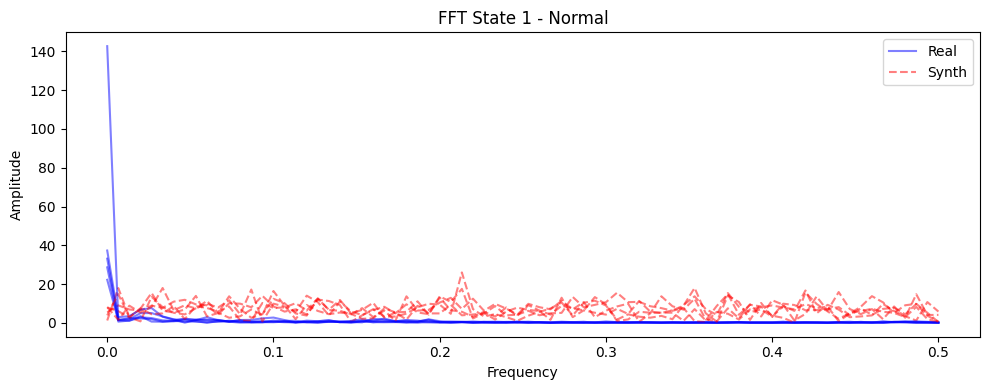

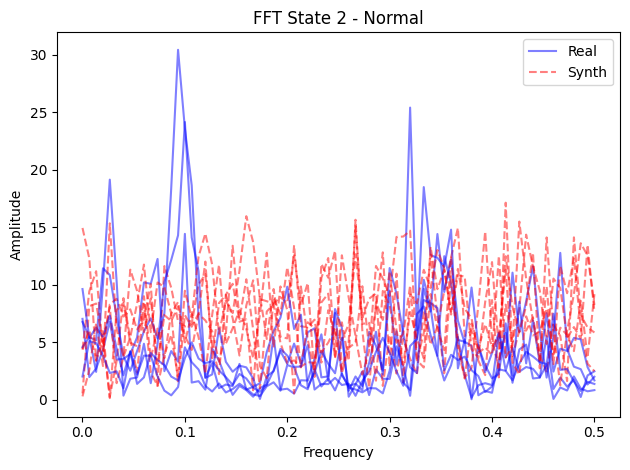

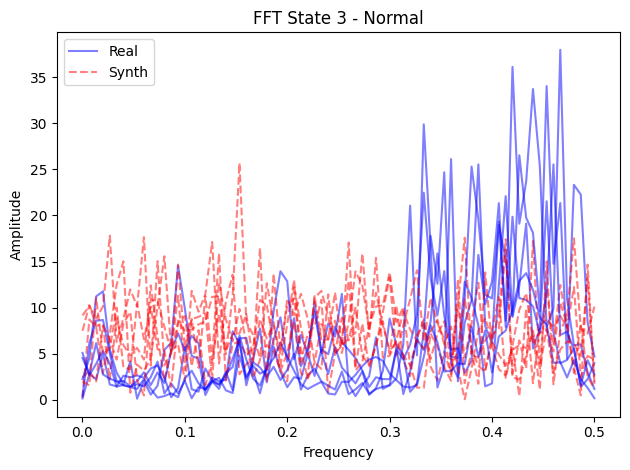

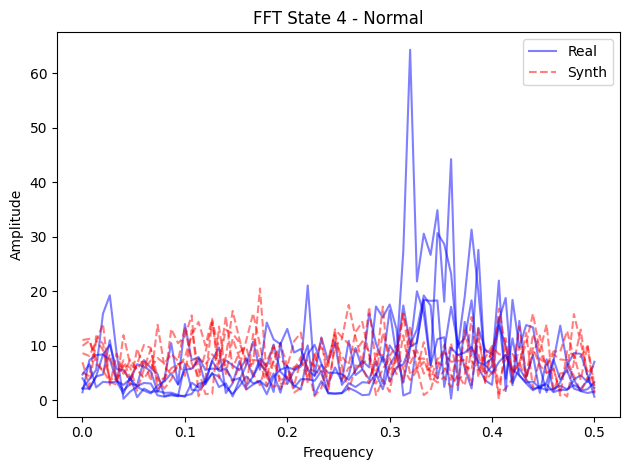

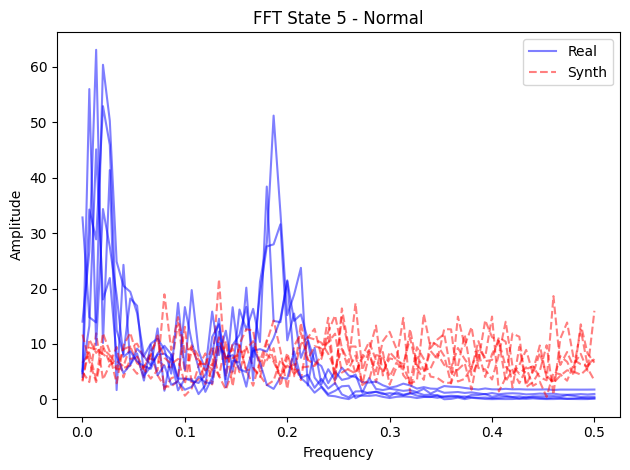

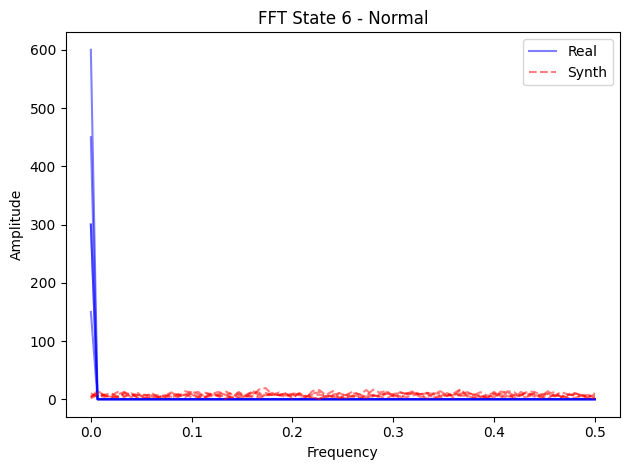

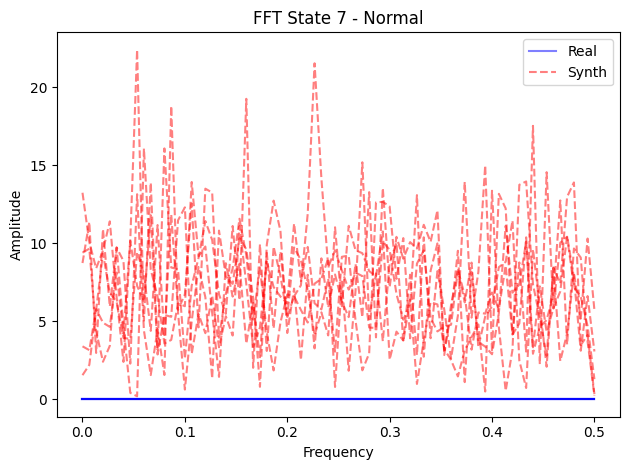

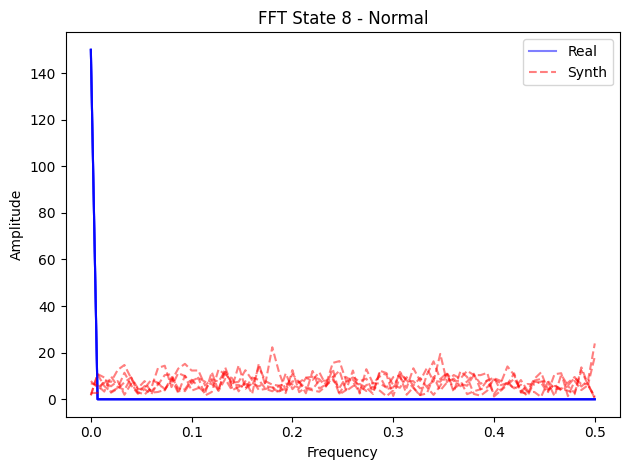

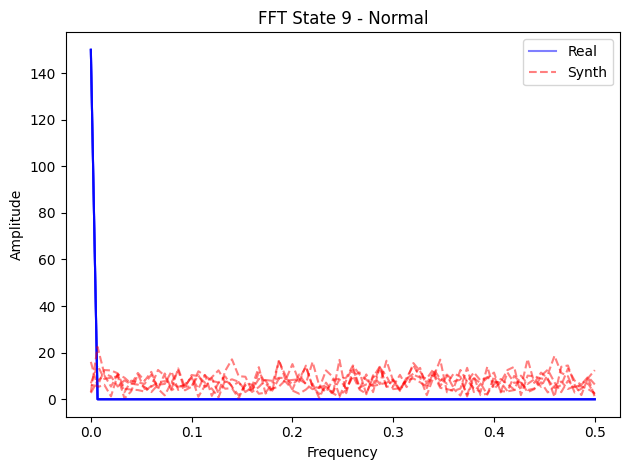

<Figure size 640x480 with 0 Axes>

In [ ]:
def plot_fft_comparison(real_segments, synthetic_data, labels, num_samples=3):
    n = real_segments.shape[1]
    freq = np.fft.rfftfreq(n, d=1)
    plt.figure(figsize=(10, 4))
    for i in range(real_segments.shape[-1]):
        for j in range(num_samples):
            real_fft = np.abs(np.fft.rfft(real_segments[j, :, i]))
            synth_fft = np.abs(np.fft.rfft(synthetic_data[j, :, i]))
            plt.plot(freq, real_fft, color='b', alpha=0.5, label='Real' if j==0 else "")
            plt.plot(freq, synth_fft, color='r', alpha=0.5, linestyle='--', label='Synth' if j==0 else "")
        plt.title(f'FFT State {i+1} - {"Fault" if labels[i] == 1 else "Normal"}')
        plt.xlabel('Frequency')
        plt.ylabel('Amplitude')
        plt.legend()
        plt.tight_layout()
        plt.savefig('syn_vs_real_singleFault.png')
        plt.show()
    plt.savefig('syn_vs_real_data_gearset.png')

plot_fft_comparison(real_data, syn_data.cpu(), gear_state, num_samples=5)


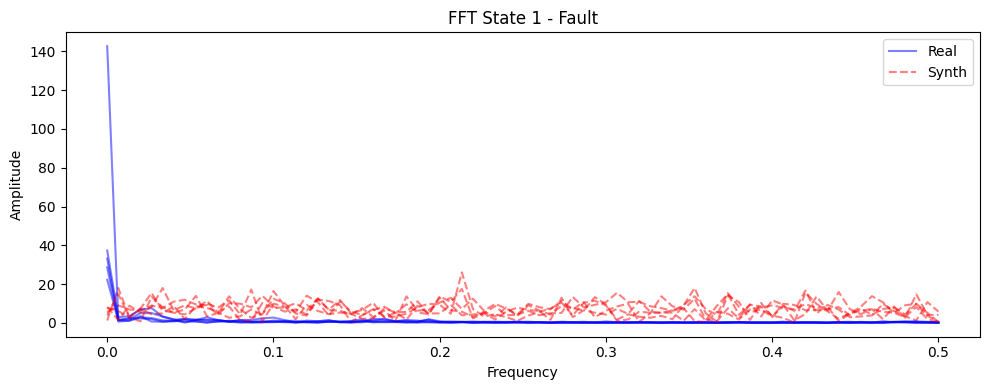

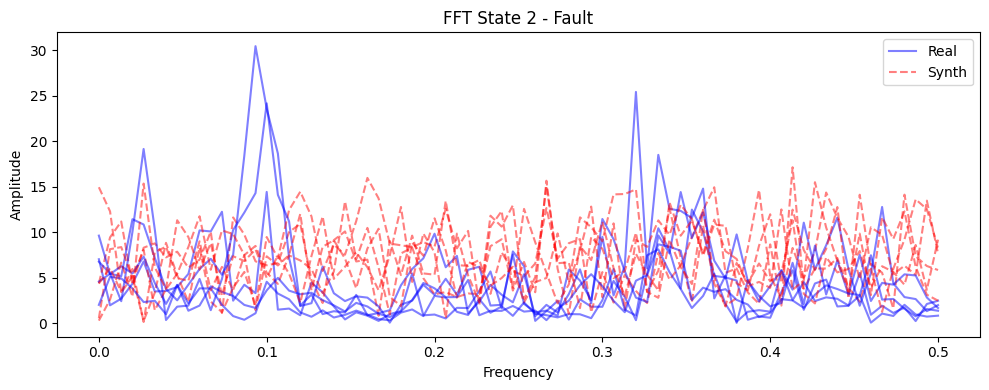

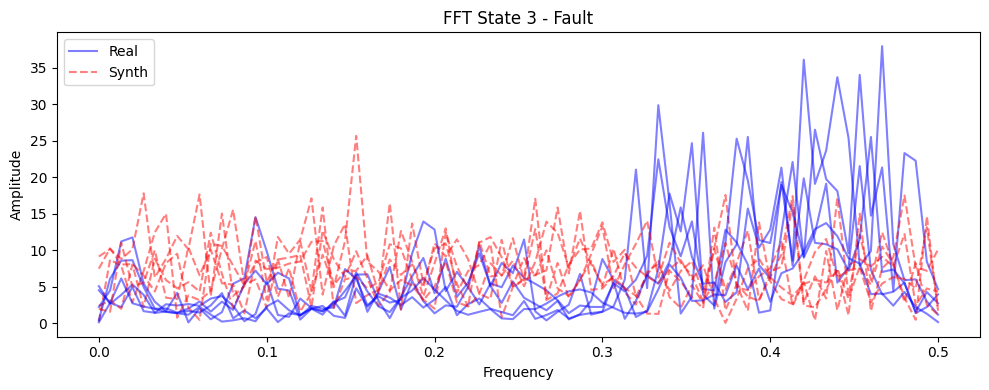

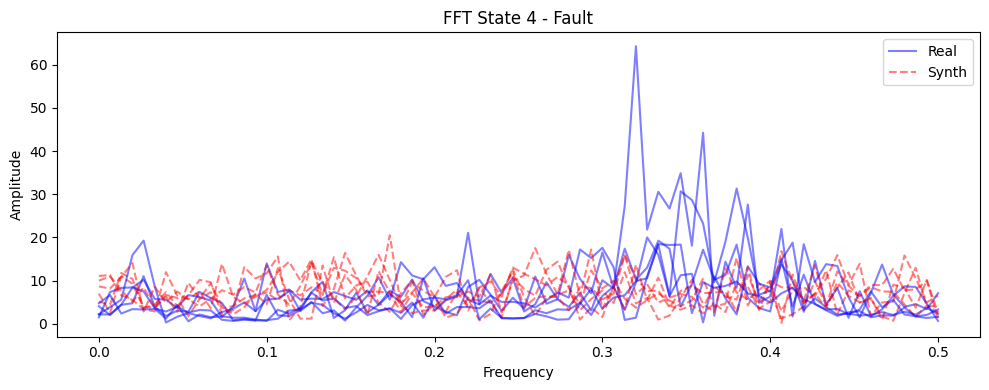

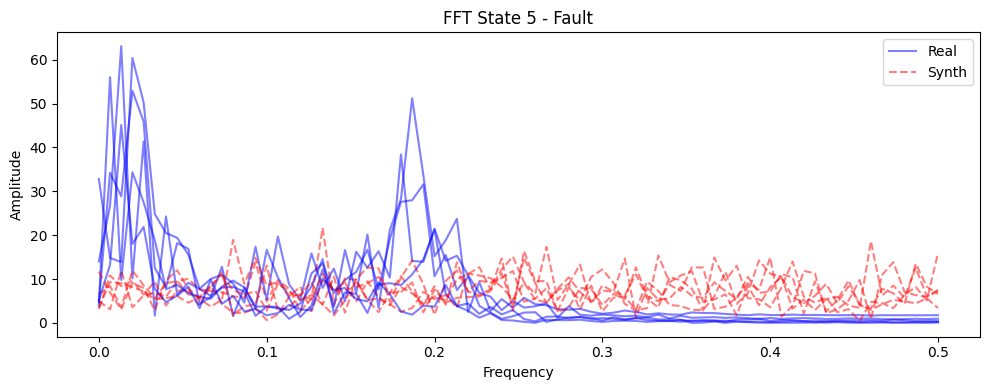

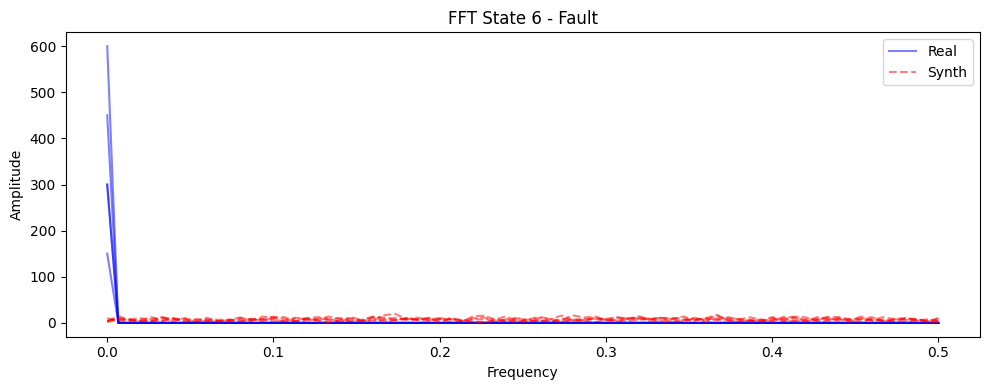

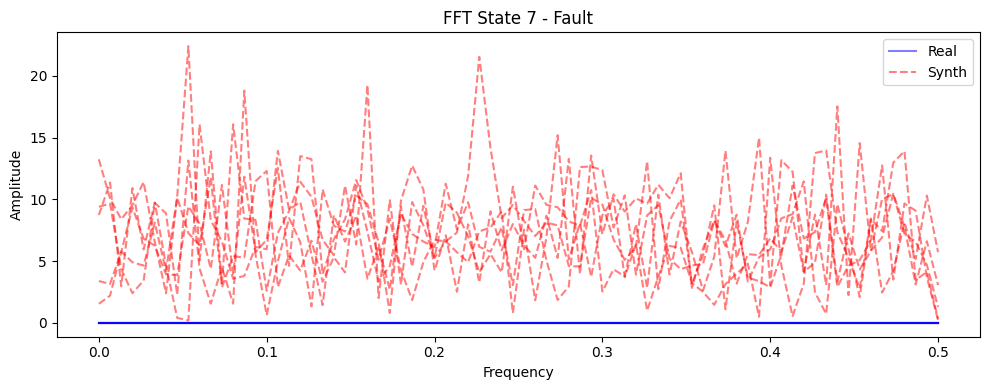

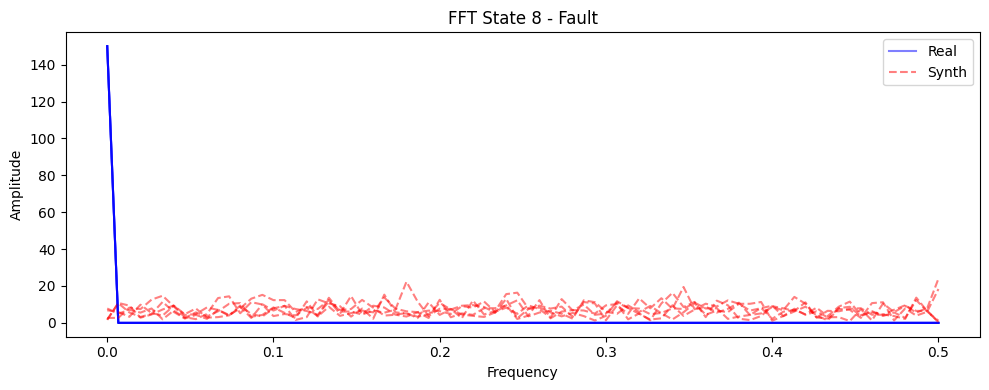

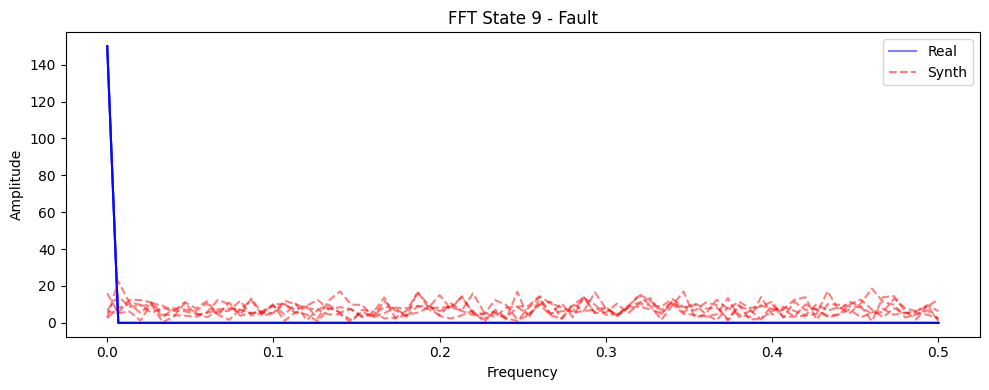

In [ ]:
plot_fft_comparison(real_data, syn_data.cpu(), bearing_state, num_samples=5)

In [ ]:
coeffs = adam_sindy_model_singleFault.get_sparse_coefficients(threshold=0.01)
print("SINDy coeffs min/max:", coeffs.min().item(), coeffs.max().item())


SINDy coeffs min/max: -0.2610021233558655 0.2710985243320465


In [ ]:
syn_data[0][:,:]

tensor([[ 1.2398, -0.1745, -0.2766,  ...,  0.8971, -0.3821, -0.7700],
        [ 0.5196, -0.2100,  0.1130,  ...,  0.4664,  0.4133,  0.3224],
        [ 1.4012, -0.0043,  0.4121,  ...,  0.3270,  0.0250,  0.1445],
        ...,
        [ 0.1439, -0.0637,  0.1936,  ..., -0.4091,  1.2597, -0.3050],
        [-0.2626, -1.0780, -0.5191,  ..., -0.3421, -0.0222, -0.5257],
        [-0.1349,  0.3940,  0.0343,  ..., -1.1054, -0.5981, -0.3587]],
       device='cuda:0')

In [ ]:

def plot_time_series_comparison_with_synth_labels(
    real,
    synthetic,
    real_labels,               # array/list of length num_samples (real data labels)
    n_sensor_features,
    n_cond_cat,
    n_cond_cont,
    sensor_feature_names,
    num_samples=3
):
    """
    real, synthetic: [num_samples, seq_len, input_dim]
    real_labels: array/list of length num_samples (e.g., 0=healthy, 1=faulty)
    n_sensor_features: int
    n_cond_cat: int (number of one-hot categorical condition features)
    n_cond_cont: int (number of continuous condition features)
    sensor_feature_names: list of strings, length = number of sensor features
    num_samples: number of samples to plot per feature

    This function extracts synthetic labels from the categorical condition features
    in synthetic data and uses real_labels for real data.
    """

    time = np.arange(real.shape[1])
    num_features = n_sensor_features

    # Extract synthetic labels from synthetic conditional categorical features
    # Use first timestep (or average over time) for label extraction
    cond_cat_synth = synthetic[:, 0, n_sensor_features : n_sensor_features + n_cond_cat]  # shape [batch, n_cond_cat]
    if isinstance(cond_cat_synth, torch.Tensor):
        cond_cat_synth = cond_cat_synth.detach().cpu().numpy()
    synth_labels = np.argmax(cond_cat_synth, axis=1)  # shape [batch]

    # Helper function to map label index to healthy/faulty
    def label_to_status(label):
        # Example: label 0 means healthy, others faulty
        return "Healthy" if label == 0 else "Faulty"

    for i in range(num_features):
        plt.figure(figsize=(10, 4))
        for j in range(num_samples):
            # Plot real data
            status_real = label_to_status(real_labels[j])
            plt.plot(time, real[j, :, i], label=f'Real {j+1} ({status_real})', color='b', alpha=0.5)
            # Plot synthetic data
            status_synth = label_to_status(synth_labels[j])
            plt.plot(time, synthetic[j, :, i], label=f'Synth {j+1} ({status_synth})', color='r', alpha=0.5, linestyle='--')

        plt.title(f'{sensor_feature_names[i]}')
        plt.xlabel('Time')
        plt.ylabel('Value')
        plt.legend()
        plt.tight_layout()
        plt.show()


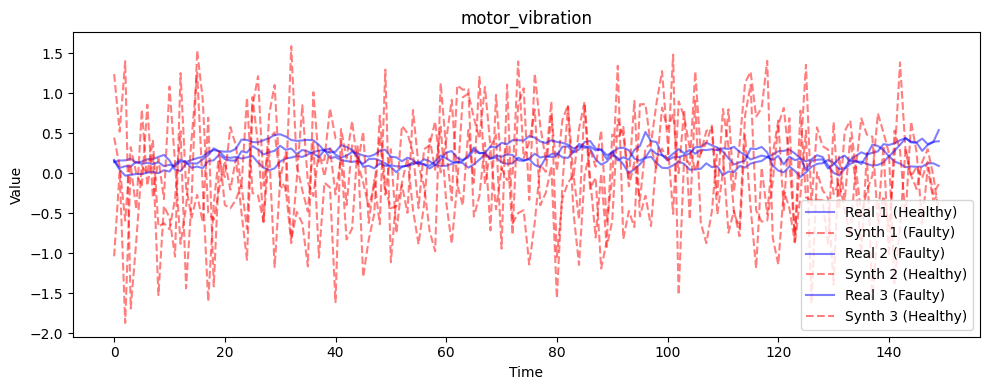

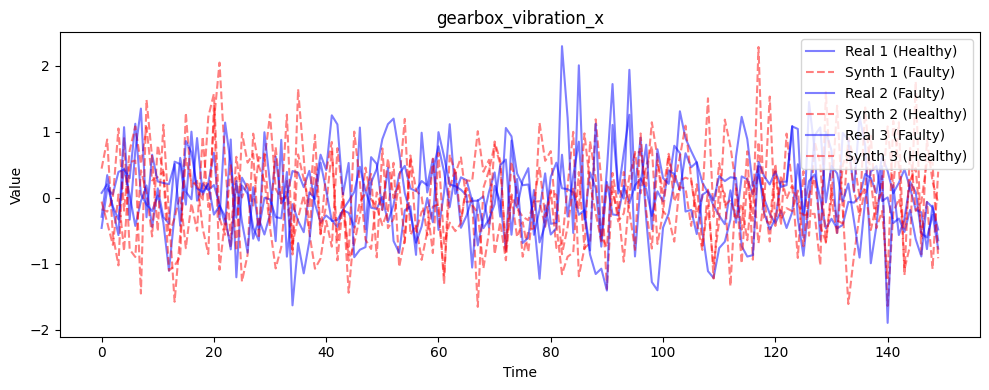

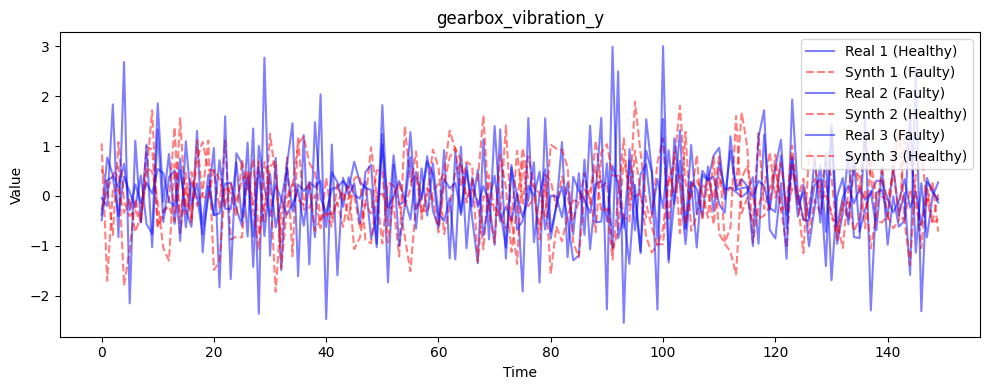

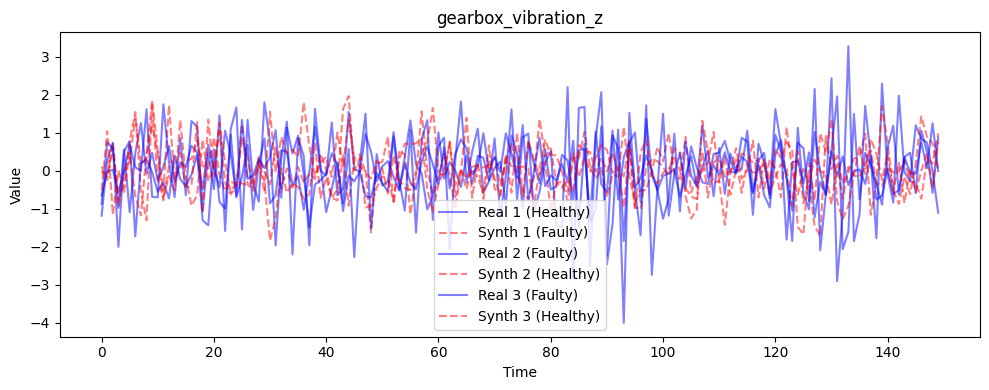

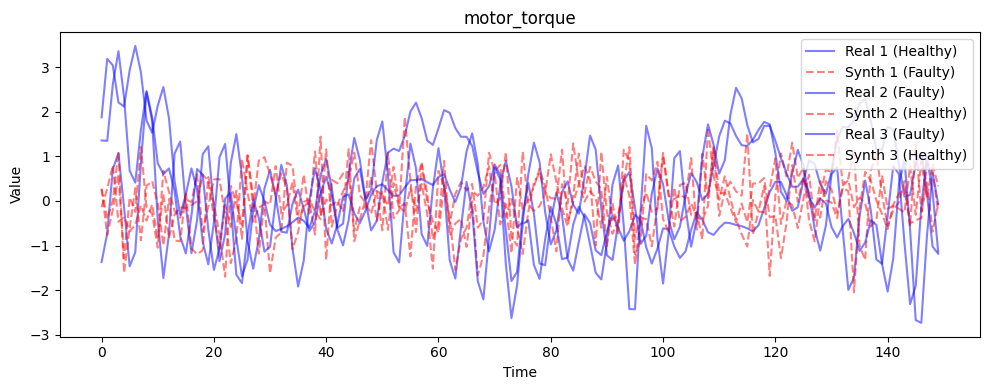

In [ ]:
plot_time_series_comparison_with_synth_labels(
    real=real_data,
    synthetic=syn_data.cpu(),
    real_labels=[0,1,2,3],  # e.g., [0,0,1,0,1,...] length = num_samples
    n_sensor_features=len(sensor_columns),
    n_cond_cat=len(condition_columns_cat),
    n_cond_cont=len(conditions_columns_cont),
    sensor_feature_names=sensor_columns,
    num_samples=3
)


In [ ]:
plot_time_series_comparison_with_synth_labels(
    real=real_data,
    synthetic=syn_data.cpu(),
    real_labels=bearing_state,  # e.g., [0,0,1,0,1,...] length = num_samples
    n_sensor_features=len(sensor_columns),
    n_cond_cat=len(condition_columns_cat),
    n_cond_cont=len(conditions_columns_cont),
    sensor_feature_names=sensor_columns,
    num_samples=3
)


NameError: name 'plot_time_series_comparison_with_synth_labels' is not defined

In [ ]:
def plot_aggregate_time_series(data, labels, sensor_feature_names, title_suffix=""):
    # Ensure data and labels are numpy arrays on CPU
    if isinstance(data, torch.Tensor):
        data = data.detach().cpu().numpy()
    if isinstance(labels, torch.Tensor):
        labels = labels.detach().cpu().numpy()
    labels = np.array(labels)

    print("Data shape:", data.shape)
    print("Labels shape:", labels.shape)
    print("Unique labels:", np.unique(labels))

    time = np.arange(data.shape[1])
    num_features = data.shape[2]

    healthy_idx = np.where(labels == 0)[0]
    faulty_idx = np.where(labels != 0)[0]

    for i in range(num_features):
        plt.figure(figsize=(10, 4))
        if len(healthy_idx) > 0:
            healthy_data = data[healthy_idx, :, i]
            healthy_mean = healthy_data.mean(axis=0)
            healthy_std = healthy_data.std(axis=0)
            plt.plot(time, healthy_mean, label='Healthy Mean', color='green')
            plt.fill_between(time, healthy_mean - healthy_std, healthy_mean + healthy_std, color='green', alpha=0.3)
        if len(faulty_idx) > 0:
            faulty_data = data[faulty_idx, :, i]
            faulty_mean = faulty_data.mean(axis=0)
            faulty_std = faulty_data.std(axis=0)
            plt.plot(time, faulty_mean, label='Faulty Mean', color='red')
            plt.fill_between(time, faulty_mean - faulty_std, faulty_mean + faulty_std, color='red', alpha=0.3)
        plt.title(f'Aggregate Time Series - {sensor_feature_names[i]} {title_suffix}')
        plt.xlabel('Time')
        plt.ylabel('Value')
        plt.legend()
        plt.tight_layout()
        plt.show()


In [ ]:
plot_aggregate_time_series(syn_data, gear_state, sensor_columns)

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


# Evaluation Code

PCA and TSNE test

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE



def plot_distribution_overlap(
    real_data,
    synthetic_data,
    n_sensor=5,
    n_cond_cat=2,
    n_cond_cont=2,
    method='pca',  # 'pca' or 'tsne'
    save_path='distribution_overlap.png'
):
    """
    Plot distribution overlap of real and synthetic data using PCA or t-SNE.

    Data shape: (num_samples, seq_len, 9)
    First 5 columns: sensor values
    Next 2 columns: categorical condition (one-hot or categorical)
    Last 2 columns: continuous condition

    The function averages over time dimension to get a feature vector per sample.
    """

    # Convert tensors to numpy if needed
    def to_numpy(x):
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
        return x

    real_data = to_numpy(real_data)
    synthetic_data = to_numpy(synthetic_data)

    # Average over time dimension to get shape (num_samples, 9)
    real_avg = real_data.mean(axis=1)
    synth_avg = synthetic_data.mean(axis=1)

    # Extract categorical labels from the categorical condition features (columns 5 and 6)
    # If one-hot encoded, take argmax; if categorical integer, use directly
    def extract_labels(cat_features):
        # If one-hot, argmax
        if cat_features.shape[1] == n_cond_cat:
            return np.argmax(cat_features, axis=1)
        else:
            # Assume categorical integer labels in shape (num_samples, 1)
            return cat_features.flatten()

    real_cat = real_avg[:, n_sensor:n_sensor + n_cond_cat]
    synth_cat = synth_avg[:, n_sensor:n_sensor + n_cond_cat]

    real_labels = extract_labels(real_cat)
    synth_labels = extract_labels(synth_cat)

    # Combine data for dimensionality reduction
    combined_data = np.concatenate([real_avg, synth_avg], axis=0)

    # Create source labels: 0=real, 1=synthetic
    source_labels = np.array([0] * real_avg.shape[0] + [1] * synth_avg.shape[0])

    # Create combined health/fault labels
    combined_health_labels = np.concatenate([real_labels, synth_labels], axis=0)

    # Dimensionality reduction
    if method.lower() == 'pca':
        reducer = PCA(n_components=2)
    elif method.lower() == 'tsne':
        reducer = TSNE(n_components=2, random_state=42)
    else:
        raise ValueError("method must be 'pca' or 'tsne'")

    reduced = reducer.fit_transform(combined_data)

    # Plotting
    plt.figure(figsize=(10, 8))

    # Plot real and synthetic points with different markers and colors by health/faulty label
    markers = ['o', 's']  # real: circle, synthetic: square
    colors = ['green', 'red', 'blue', 'purple']  # up to 4 classes (0=no-fault, 1,2,3 faults)

    for src in [0, 1]:
        for label in np.unique(combined_health_labels):
            idxs = np.where((source_labels == src) & (combined_health_labels == label))[0]
            if len(idxs) == 0:
                continue
            plt.scatter(
                reduced[idxs, 0],
                reduced[idxs, 1],
                marker=markers[src],
                color=colors[label],
                alpha=0.6,
                label=f"{'Real' if src==0 else 'Synth'} - Label {label}"
            )

    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.title(f'Distribution Overlap of Real and Synthetic Data ({method.upper()})')
    plt.legend(loc='best', fontsize='small')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()
    print(f"Saved distribution overlap plot to {save_path}")


In [ ]:
plot_distribution_overlap(
    real_data=real_data,          # shape (256, 250, 9)
    synthetic_data=synthetic_data_noPhysics, # same shape
    n_sensor=5,
    n_cond_cat=2,
    n_cond_cont=2,
    method='pca',                       # or 'tsne'
    save_path='dist_overlap_pca_1.png'
)


Saved distribution overlap plot to dist_overlap_pca_1.png


In [ ]:
plot_distribution_overlap(
    real_data=real_data,          # shape (256, 250, 9)
    synthetic_data=syn_data, # same shape
    n_sensor=5,
    n_cond_cat=2,
    n_cond_cont=2,
    method='tsne',                       # or 'tsne'
    save_path='dist_overlap_tsne.png'
)


Saved distribution overlap plot to dist_overlap_tsne.png


MMD and Centroid distance calculation

In [ ]:

from scipy.spatial.distance import cdist

def preprocess_data(data, n_sensor=5, n_cond_cat=2):
    """
    Convert time series data (num_samples, seq_len, features) to feature vectors by averaging over time.
    Extract categorical labels from categorical condition features.
    """
    if isinstance(data, np.ndarray):
        data_np = data
    else:
        data_np = data.detach().cpu().numpy()

    # Average over time dimension
    features_avg = data_np.mean(axis=1)  # shape: (num_samples, features)

    # Extract categorical condition features (assumed one-hot)
    cond_cat = features_avg[:, n_sensor:n_sensor + n_cond_cat]

    # Convert one-hot to labels
    labels = np.argmax(cond_cat, axis=1)

    return features_avg, labels

def gaussian_kernel(x, y, sigma=1.0):
    """Compute Gaussian kernel matrix between x and y."""
    dists = cdist(x, y, 'sqeuclidean')
    return np.exp(-dists / (2 * sigma ** 2))

def compute_mmd(x, y, sigma=1.0):
    """
    Compute squared Maximum Mean Discrepancy (MMD) between samples x and y.
    x, y: numpy arrays of shape (num_samples, features)
    """
    Kxx = gaussian_kernel(x, x, sigma)
    Kyy = gaussian_kernel(y, y, sigma)
    Kxy = gaussian_kernel(x, y, sigma)

    m = x.shape[0]
    n = y.shape[0]

    mmd = (Kxx.sum() - np.trace(Kxx)) / (m * (m - 1)) \
        + (Kyy.sum() - np.trace(Kyy)) / (n * (n - 1)) \
        - 2 * Kxy.mean()

    return mmd

def compute_cluster_centroid_distances(real_features, real_labels, synth_features, synth_labels):
    """
    Compute Euclidean distances between cluster centroids of real and synthetic data per label.
    Returns dict: {label: distance}
    """
    distances = {}
    unique_labels = np.unique(np.concatenate([real_labels, synth_labels]))
    for label in unique_labels:
        real_cluster = real_features[real_labels == label]
        synth_cluster = synth_features[synth_labels == label]

        if len(real_cluster) == 0 or len(synth_cluster) == 0:
            distances[label] = np.nan  # No data for this label
            continue

        centroid_real = real_cluster.mean(axis=0)
        centroid_synth = synth_cluster.mean(axis=0)
        dist = np.linalg.norm(centroid_real - centroid_synth)
        distances[label] = dist
    return distances



In [ ]:
# --- Example usage ---

# Assume real_data and synthetic_data are numpy arrays or torch tensors with shape (num_samples, seq_len, 9)
# n_sensor=5, n_cond_cat=2 as per your setup

real_features, real_labels = preprocess_data(real_data, n_sensor=5, n_cond_cat=2)
synth_features, synth_labels = preprocess_data(syn_data, n_sensor=5, n_cond_cat=2)

mmd_value = compute_mmd(real_features, synth_features, sigma=1.0)
print(f"MMD between real and synthetic data: {mmd_value:.6f}")

centroid_distances = compute_cluster_centroid_distances(real_features, real_labels, synth_features, synth_labels)
for label, dist in centroid_distances.items():
    print(f"Centroid distance for label {label}: {dist:.6f}")


MMD between real and synthetic data: 0.979731
Centroid distance for label 0: 2.521385
Centroid distance for label 1: 2.446151


# TSTR Test

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

def tune_svm_with_cv(X_train, y_train, random_state=42):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 0.001, 0.01, 0.1, 1],
        'kernel': ['rbf', 'linear']
    }

    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=random_state)

    grid_search = GridSearchCV(
        estimator=SVC(random_state=random_state),
        param_grid=param_grid,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train_scaled, y_train)
    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    best_model = grid_search.best_estimator_
    scores = cross_val_score(best_model, X_train_scaled, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    mean_acc = np.mean(scores)
    std_acc = np.std(scores)
    ci95 = 1.96 * std_acc / np.sqrt(len(scores))  # 95% confidence interval

    print(f"SVM best params: {best_params}")
    print(f"SVM mean CV accuracy: {mean_acc:.4f} ± {ci95:.4f} (95% CI)")

    return best_model, scaler

def train_evaluate_classifiers_from_features_with_svm_tuning(
    synthetic_features,
    synthetic_labels,
    real_features,
    real_labels,
    num_classes=None,
    test_size=0.2,
    random_state=42
):
    if num_classes is None:
        num_classes = len(np.unique(np.concatenate([synthetic_labels, real_labels])))

    # Standardize features based on synthetic data (for training)
    scaler = StandardScaler()
    synthetic_features_scaled = scaler.fit_transform(synthetic_features)
    real_features_scaled = scaler.transform(real_features)

    print("=== Training on Synthetic, Testing on Real ===")

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=random_state)
    rf.fit(synthetic_features_scaled, synthetic_labels)
    y_pred_rf = rf.predict(real_features_scaled)
    acc_rf = accuracy_score(real_labels, y_pred_rf)
    print(f"Random Forest Accuracy: {acc_rf:.4f}")
    print(classification_report(real_labels, y_pred_rf))

    # Tune SVM with CV on synthetic data
    svm_best_model, svm_scaler = tune_svm_with_cv(synthetic_features, synthetic_labels, random_state=random_state)
    # Transform real features with svm scaler
    X_real_svm_scaled = svm_scaler.transform(real_features)
    y_pred_svm = svm_best_model.predict(X_real_svm_scaled)
    acc_svm = accuracy_score(real_labels, y_pred_svm)
    print(f"SVM Test Accuracy on Real Data: {acc_svm:.4f}")
    print(classification_report(real_labels, y_pred_svm))

    # MLP Classifier
    mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=random_state)
    mlp.fit(synthetic_features_scaled, synthetic_labels)
    y_pred_mlp = mlp.predict(real_features_scaled)
    acc_mlp = accuracy_score(real_labels, y_pred_mlp)
    print(f"MLP Classifier Accuracy: {acc_mlp:.4f}")
    print(classification_report(real_labels, y_pred_mlp))

    print("\n=== Training on Real, Testing on Real (Baseline) ===")

    # Split real data into train/test for baseline
    X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
        real_features_scaled, real_labels, test_size=test_size, random_state=random_state)

    # Random Forest baseline
    rf_baseline = RandomForestClassifier(n_estimators=100, random_state=random_state)
    rf_baseline.fit(X_train_real, y_train_real)
    y_pred_rf_base = rf_baseline.predict(X_test_real)
    print(f"RF Baseline Accuracy: {accuracy_score(y_test_real, y_pred_rf_base):.4f}")

    # SVM baseline with tuning on real train data
    svm_baseline_model, svm_baseline_scaler = tune_svm_with_cv(X_train_real, y_train_real, random_state=random_state)
    X_test_real_svm_scaled = svm_baseline_scaler.transform(X_test_real)
    y_pred_svm_base = svm_baseline_model.predict(X_test_real_svm_scaled)
    print(f"SVM Baseline Accuracy: {accuracy_score(y_test_real, y_pred_svm_base):.4f}")

    # MLP baseline
    mlp_baseline = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=random_state)
    mlp_baseline.fit(X_train_real, y_train_real)
    y_pred_mlp_base = mlp_baseline.predict(X_test_real)
    print(f"MLP Baseline Accuracy: {accuracy_score(y_test_real, y_pred_mlp_base):.4f}")
    print(classification_report(y_test_real, y_pred_mlp_base))

    return {
        'rf_synth_test_real': acc_rf,
        'svm_synth_test_real': acc_svm,
        'mlp_synth_test_real': acc_mlp,
        'rf_real_test_real': accuracy_score(y_test_real, y_pred_rf_base),
        'svm_real_test_real': accuracy_score(y_test_real, y_pred_svm_base),
        'mlp_real_test_real': accuracy_score(y_test_real, y_pred_mlp_base)
    }


In [ ]:
type(real_data)

numpy.ndarray

In [ ]:
results = train_evaluate_classifiers_from_features_with_svm_tuning(
    synthetic_features=synth_features,
    synthetic_labels=synth_labels,
    real_features=real_features,
    real_labels=real_labels
)

print(results)

=== Training on Synthetic, Testing on Real ===
Random Forest Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       497
           1       1.00      1.00      1.00       503

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

SVM best params: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
SVM mean CV accuracy: 0.9927 ± 0.0028 (95% CI)
SVM Test Accuracy on Real Data: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       497
           1       1.00      1.00      1.00       503

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

MLP Classifier Accuracy: 0.9990
              precision    recall  f1-score   support

           0       1.00      

In [ ]:
real_features.shape

(256, 9)

Baseline Model Comparision

In [ ]:
import copy
class VanillaDiffusionModel(nn.Module):
    def __init__(
        self,
        input_dim,
        seq_len,
        d_model=256,
        nhead=8,
        num_encoder_layers=6,
        dim_feedforward=1024,
        dropout=0.1,
        num_timesteps=1000,
        beta_start=1e-4,
        beta_end=0.02,
        poly_order=2
    ):
        super().__init__()

        self.scheduler = NoiseScheduler(num_timesteps, beta_start, beta_end)
        self.network = TimeSeriesTransformer(
            input_dim=input_dim,
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout
        )
        self.diffusion = DiffusionModel(input_dim, self.scheduler, self.network)

        self.input_dim = input_dim
        self.seq_len = seq_len

    def forward(self, x_0, t=None):
        noise_pred, noise, x_t, t = self.diffusion(x_0, t)

        diffusion_loss = F.mse_loss(noise_pred, noise)

        # Predict clean data from noisy sample
        alpha_cumprod = self.scheduler.alphas_cumprod[t].reshape(-1, 1, 1)
        sqrt_one_minus_alphas_cumprod = self.scheduler.sqrt_one_minus_alphas_cumprod[t].reshape(-1, 1, 1)
        x_0_pred = (x_t - sqrt_one_minus_alphas_cumprod * noise_pred) / torch.sqrt(alpha_cumprod)

        total_loss = diffusion_loss

        return total_loss

    @torch.no_grad()
    def sample(self, batch_size, device):
        return self.diffusion.sample(batch_size, self.seq_len, device)


In [ ]:
import os
from tqdm import tqdm
from torch.amp import autocast, GradScaler

def train_vanilla_diffusion(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs,
    start_epoch=0,
    save_path=None,
    scheduler_patience=5,
    scheduler_factor=0.5,
    early_stopping_patience=15,
    checkpoint_path=None  # Path to load checkpoint for resuming
):
    # Initialize or load training history
    if checkpoint_path and os.path.isfile(checkpoint_path):
        print(f"Loading checkpoint from {checkpoint_path} to resume training...")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        history = checkpoint.get('history', {
            'train_total_loss': [],
            'val_total_loss': []
        })
        best_val_loss = checkpoint.get('val_loss', float('inf'))
        print(f"Resuming from epoch {start_epoch} with best val loss {best_val_loss:.6f}")
    else:
        history = {
            'train_total_loss': [],
            'val_total_loss': []
        }
        best_val_loss = float('inf')

    gradScaler = GradScaler()
    early_stop_counter = 0
    model.train()

    for epoch in range(start_epoch, num_epochs):
        epoch_total_loss = 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs-1}")

        for batch_idx, (data, condition_cat_data, condition_cont_data, target_data) in enumerate(pbar):
            combined_data = torch.cat([data, condition_cat_data, condition_cont_data], dim=-1).to(device)
            optimizer.zero_grad()

            with autocast(device_type=device.type):
                total_loss = model(combined_data)

            gradScaler.scale(total_loss).backward()
            gradScaler.step(optimizer)
            gradScaler.update()

            epoch_total_loss += total_loss.detach().item()

            pbar.set_postfix({

                'total_loss': f"{total_loss.item():.6f}"
            })

        # Compute average losses for the epoch
        avg_total_loss = epoch_total_loss / len(train_loader)

        print(f"Epoch {epoch} Training Summary:  Avg Total Loss={avg_total_loss:.6f}")

        # Validation step every epoch (adjust if needed)
        if val_loader is not None:
            model.eval()
            val_total_loss = 0.0
            val_batches = 0
            vbar = tqdm(val_loader, desc="Validation")

            with torch.no_grad():
                for val_data, val_condition_cat_data, val_condition_cont_data, val_target_data in vbar:
                    combined_val_data = torch.cat([val_data, val_condition_cat_data, val_condition_cont_data], dim=-1).to(device)
                    total_loss = model(combined_val_data)
                    val_total_loss += total_loss.detach().item()
                    val_batches += 1
                    vbar.set_postfix({
                        'val_total_loss': f"{total_loss.item():.6f}"
                    })

            avg_val_total_loss = val_total_loss / val_batches

            print(f"Epoch {epoch} Validation Summary: Avg Total Loss={avg_val_total_loss:.6f}")

            # Append to history
            history['train_total_loss'].append(avg_total_loss)
            history['val_total_loss'].append(avg_val_total_loss)


            # Early stopping check
            if avg_val_total_loss < best_val_loss:
                best_val_loss = avg_val_total_loss
                early_stop_counter = 0

                # Save best model checkpoint
                if save_path is not None:
                    os.makedirs(save_path, exist_ok=True)
                    checkpoint_file = os.path.join(save_path, "pi2tsd_best_model_no_physics.pth")
                    torch.save({
                        'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'loss': avg_val_total_loss,
                        'history': history,
                        'val_loss': avg_val_total_loss,
                        'train_loss': avg_total_loss
                    }, checkpoint_file)
                    print(f"Saved best model checkpoint to {checkpoint_file}")

            else:
                early_stop_counter += 1
                print(f"No improvement in validation loss. Early stop counter: {early_stop_counter}/{early_stopping_patience}")

            if early_stop_counter >= early_stopping_patience:
                print(f"Early stopping triggered at epoch {epoch}.")
                break

            model.train()

        else:
            # If no validation loader, just append train loss to history
            history['train_total_loss'].append(avg_total_loss)

    return model, history


In [ ]:
model_without_physics_singleFault = VanillaDiffusionModel(
    input_dim=input_dim,
    seq_len=seq_len,
    d_model=batch_size,
    nhead=8,
    num_encoder_layers=6,
    dim_feedforward=1024,
    dropout=0.1,
    num_timesteps=1000,
    beta_start=1e-4,
    beta_end=0.02,
    poly_order=2
).to(device)

In [ ]:
optimiser = torch.optim.Adam(model_without_physics_singleFault.parameters(), lr=learning_rate)

In [ ]:
pi2tsd_model_vanilla, history_pi2tsd_vanilla = train_vanilla_diffusion(
    model_without_physics_singleFault,
    train_loader_singleFault,
    test_loader_singleFault,
    optimiser,
    device=device,
    num_epochs=10,
    save_path="/content/drive/MyDrive/IEEE IES/checkpoints/",
    early_stopping_patience=15
)

Epoch 0/9: 100%|██████████| 13107/13107 [09:24<00:00, 23.22it/s, total_loss=0.127464]


Epoch 0 Training Summary:  Avg Total Loss=0.111814


Validation: 100%|██████████| 3277/3277 [01:56<00:00, 28.13it/s, val_total_loss=0.112793]


Epoch 0 Validation Summary: Avg Total Loss=0.288004
Saved best model checkpoint to /content/drive/MyDrive/IEEE IES/checkpoints/pi2tsd_best_model_no_physics.pth


Epoch 1/9: 100%|██████████| 13107/13107 [09:25<00:00, 23.18it/s, total_loss=0.092098]


...

Epoch 8 Validation Summary: Avg Total Loss=0.192917
Saved best model checkpoint to /content/drive/MyDrive/IEEE IES/checkpoints/pi2tsd_best_model_no_physics.pth


Epoch 9/9: 100%|██████████| 13107/13107 [09:20<00:00, 23.38it/s, total_loss=0.070100]


Epoch 9 Training Summary:  Avg Total Loss=0.056898


Validation: 100%|██████████| 3277/3277 [01:55<00:00, 28.35it/s, val_total_loss=0.053037]


Epoch 9 Validation Summary: Avg Total Loss=0.181335
Saved best model checkpoint to /content/drive/MyDrive/IEEE IES/checkpoints/pi2tsd_best_model_no_physics.pth


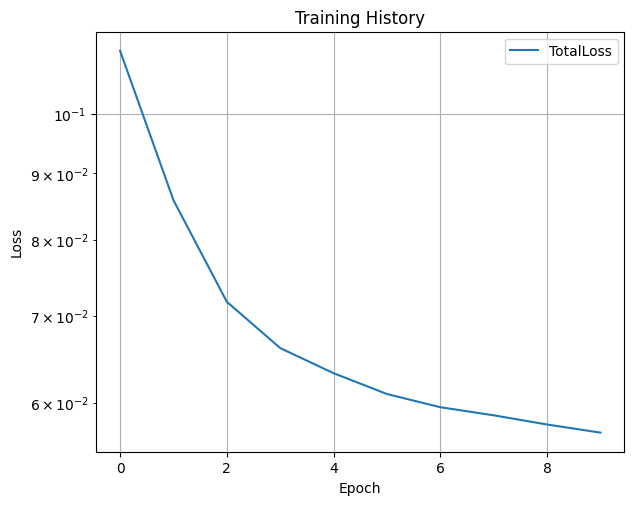

In [ ]:
import matplotlib.pyplot as plt
# Create the figure
fig = plt.figure(figsize=(15, 12))

ax1 = fig.add_subplot(2, 2, 1)
ax1.semilogy(history_pi2tsd_vanilla['train_total_loss'], label='TotalLoss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training History')
ax1.legend()
ax1.grid(True)

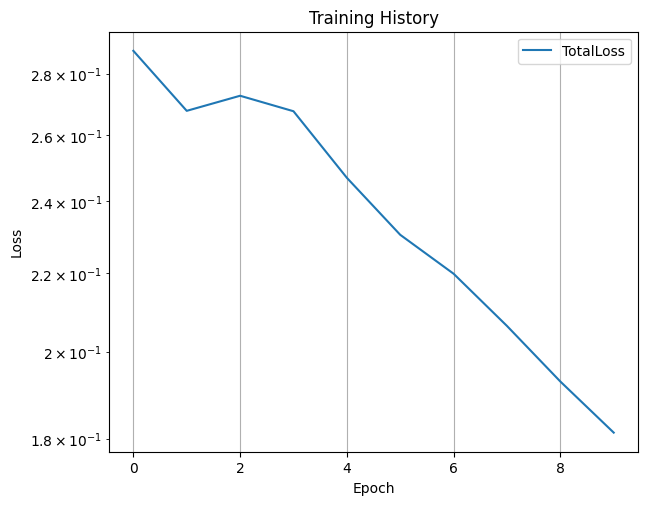

In [ ]:
import matplotlib.pyplot as plt
# Create the figure
fig = plt.figure(figsize=(15, 12))

ax1 = fig.add_subplot(2, 2, 1)
ax1.semilogy(history_pi2tsd_vanilla['val_total_loss'], label='TotalLoss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training History')
ax1.legend()
ax1.grid(True)

In [ ]:
synthetic_data_noPhysics = model_without_physics_singleFault.sample(batch_size=1000,device=device)

In [ ]:
synthetic_data_noPhysics.shape

torch.Size([1000, 250, 9])

In [ ]:
num_samples = synthetic_data_noPhysics .shape[0]
seq_len = synthetic_data_noPhysics .shape[1]
input_dim = synthetic_data_noPhysics .shape[2]

np.random.seed(42)  # For reproducibility
start_indices = np.random.choice(X_train_singleFault.shape[0] - seq_len, num_samples, replace=False)

real_data = np.stack([
    X_train_singleFault[start:start+seq_len, :]
    for start in start_indices
])

In [ ]:
real_features_noPhysics, real_labels_noPhysics = preprocess_data(real_data, n_sensor=5, n_cond_cat=2)
synth_features_noPhysics, synth_labels_noPhysics = preprocess_data(synthetic_data_noPhysics, n_sensor=5, n_cond_cat=2)

mmd_value = compute_mmd(real_features_noPhysics, synth_features_noPhysics, sigma=1.0)
print(f"MMD between real and synthetic data: {mmd_value:.6f}")

centroid_distances = compute_cluster_centroid_distances(real_features_noPhysics, real_labels_noPhysics, synth_features_noPhysics, synth_labels_noPhysics)
for label, dist in centroid_distances.items():
    print(f"Centroid distance for label {label}: {dist:.6f}")

MMD between real and synthetic data: 0.978916
Centroid distance for label 0: 2.516190
Centroid distance for label 1: 2.442898


In [ ]:
results = train_evaluate_classifiers_from_features_with_svm_tuning(
    synthetic_features=synth_features_noPhysics,
    synthetic_labels=synth_labels_noPhysics,
    real_features=real_features_noPhysics,
    real_labels=real_labels_noPhysics
)

print(results)

=== Training on Synthetic, Testing on Real ===
Random Forest Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       497
           1       1.00      1.00      1.00       503

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

SVM best params: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
SVM mean CV accuracy: 0.9933 ± 0.0037 (95% CI)
SVM Test Accuracy on Real Data: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       497
           1       1.00      1.00      1.00       503

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

MLP Classifier Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      